#### Deep Learning: Chapter 10 ISLP
##### This lab explores Deep Learning concepts and implementations as introduced in the ISLP textbook. It bridges the gap between statistical learning theory and modern neural network techniques, focusing on how deep models extend the principles of linear models, logistic regression, and other supervised learning frameworks.
##### The lab demonstrates how multilayer architectures, nonlinear activations, and gradient based optimization allow us to model complex, high-dimensional relationships in data; a fundamental shift from traditional machine learning toward representation learning.

#### Objectives
##### **-** Understand the architecture of feed-forward neural networks i.e input, hidden and output layers.
##### **-** Learn the role of activation functions such as ReLU, sigmoid and tanh.
##### **-** Implement gradient descent and backpropagation using Python frameworks.
##### **-** Explore regularization techniques such as dropout, early stopping to prevent overfitting.
##### **-** Compare deep learning performance with classical models such as Logistic regression, SVM etc.
##### **-** Visualize decision boundaries and training dynamics to interpret model behaviour.


In [ ]:
#!pip install numpy pandas matplotlib statsmodels

In [ ]:
#!pip install ISLP

In [ ]:
#! pip install torch pytorch_lightning torchinfo

In [ ]:
#!pip install torchvision

In [ ]:
#!pip install torchtext

In [1]:
import torch
import torchvision
#import torchtext
import torchmetrics
import torchinfo
import pytorch_lightning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print(torch.__version__, torchvision.__version__ )#torchtext.__version__)


2.5.1+cpu 0.20.1+cpu


In [2]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import train_test_split, GridSearchCV
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torchmetrics import MeanAbsoluteError, R2Score
from torchinfo import summary
import torchvision
from torchvision.io import read_image
from datasets import load_dataset
import re
from collections import Counter
from itertools import chain


c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### The package **pytorch_lightning** is a somewhat higher-level interface to **torch** that simplifies the specification and fitting of models by reducing the amount of boilerplate code needed.

In [3]:
from pytorch_lightning import Trainer, LightningModule
from pytorch_lightning.loggers import CSVLogger

##### In order to reproduce results we use **seed_everything()**. We will also instruct torch to use deterministic algorithms where possible.

In [4]:
from pytorch_lightning import seed_everything
import random
#seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

##### We will use several datasets shipped with torchvision for our examples: a pretrained network for image classification, as well as some transforms used for preprocessing

In [5]:
from torchvision.datasets import MNIST, CIFAR100
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import Resize, Normalize, CenterCrop, ToTensor

##### A few utilities in ISLP has been provided specifically for this lab. The **SimpleDataModule** and **SimpleModule** are simple versions of objects used in pytorch_lightning, the high level module for fitting torch models. Although more advanced uses such as computing on graphical processing units(GPUs) and parallel data processing are possible in this module, we won't be focusing much on these in this lab.
##### The **ErrorTracker** handles collections of targets and predictions over each mini-batch in the validation or test stage, allowing computation of the metric over the entire  validation or test data set.

In [6]:
from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers

##### Helper functions have also been included to load the **IMDb** database, as well as a lookup that maps integers to particular keys in the database. Modified copy of the preprocessed **IMDb** data was used from **keras**, a separate package for fitting deep learning models.

In [7]:
from ISLP.torch.imdb import load_lookup, load_tensor, load_sparse, load_sequential

c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\ISLP\torch\imdb.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


##### The **glob()** function from **glob** module is used to find all files matching wildcard characters, which we will use in the example applying the **ResNet50** model to some of our own images. The **json** module will be used to load JSON file for looking up classes to identify the labels of the pictures in the **ResNet50** example.

In [8]:
from glob import glob
import json

#### Single Layer Network on Hitters Data

In [10]:
# We start by fitting the models on the Hitters data.
Hitters = load_data("Hitters").dropna()
n = Hitters.shape[0]

##### We will fit two linear models (least squares and lasso) and compare their performance to that of a neural network. For this comparison we will use mean absolute error on a validatiob dataset.

In [11]:
#We set up the model matrix and the response
model = MS(Hitters.columns.drop("Salary"), intercept=False)
X = model.fit_transform(Hitters).to_numpy()
Y= Hitters["Salary"].to_numpy()

#The to_numpy() method converts pandas data frames or series to numpy arrays. We do thus because we will need to use sklearn to fit the lasso model and it requires this conversion.

##### We now split the data into test and training, fixing a random state.

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3, random_state=1)

#### Linear Models

##### We fit the linear model and evaluate the test error directly.

In [13]:
hit_lm = LinearRegression().fit(X_train, Y_train)
Yhat_test = hit_lm.predict(X_test)
np.abs(Yhat_test - Y_test).mean()

np.float64(259.7152883314629)

##### Next we fit the lasso using sklearn. We are using mean absolute error to select and evaluate a model, rather than mean squared error.

##### We encode a pipeline with two steps: we first normalize the features using a **StandardScaler()** transform, and then fit the lasso without further normalization.

In [14]:
scaler = StandardScaler(with_mean=True, with_std=True)
lasso = Lasso(warm_start=True, max_iter=30000)
standard_lasso = Pipeline(steps=[("scaler", scaler), ("lasso", lasso)])

##### We need to create a grid of values for λ. As is a common practice, we choose a grid of 100 values of λ, uniform on the log scale from **lam_max** down to **0.01 * lam_max**. Here **lam_max** is the smallest value of λ with all zero solution. This value equals the largest absolute inner-product between any predictor and the centered response.

In [15]:
X_s = scaler.fit_transform(X_train)
n= X_s.shape[0]
lam_max = np.fabs(X_s.T.dot(Y_train - Y_train.mean())).max() / n
param_grid = {"alpha": np.exp(np.linspace(0, np.log(0.01), 100))* lam_max}

##### Note that we had to transform the data first, since the scale of the variables impacts the choice of λ. We now perform cross-validation using the sequence of λ values.

In [16]:
cv = KFold(10, shuffle=True, random_state=1)
grid = GridSearchCV(lasso, 
                   param_grid,
                   cv=cv,
                   scoring="neg_mean_absolute_error")
grid.fit(X_train, Y_train)

,estimator,Lasso(max_ite...rm_start=True)
,param_grid,{'alpha': array([255.65... 2.5565755 ])}
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(176.21483255243294)


##### We extract the lasso model with best cross-validated mean absolute error and evaluate its performance on X_test and Y_test, which are not used in cross-validation.

In [17]:
trained_lasso = grid.best_estimator_
Yhat_test = trained_lasso.predict(X_test)
np.fabs(Yhat_test - Y_test).mean()

np.float64(257.2382010799507)

#### Specifying a Network: Classes and Inheritance

##### To fit the neural network, we first set up a model structure that describes the network. Doing so requires us to define new classes specific to the model we wish to fit. Typically this is done in **pytorch** by sub-classing a generic representation of a network, which is the approach we take here.

In [18]:
class HittersModel(nn.Module):

    def __init__(self, input_size):
        super(HittersModel, self).__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(input_size, 50), #Takes all the features and outputs 50 linear combinations(50 hidden neurons)
            nn.ReLU(), #applies ReLU nonlinearity
            nn.Dropout(0.4), # randomly drops 40% of neurons during training to prevent overfitting
            nn.Linear(50, 1)) # Maps the 50 hidden fetures to one final output
    def forward(self, x): #this defines how the data flows forward through the network
        x = self.flatten(x)
        return torch.flatten(self.sequential(x)) #pass data through all layers defined in self.sequential and ensures the final output is a 1D tensor
        
        

In [19]:
hit_model = HittersModel(X.shape[1])
hit_model

HittersModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (sequential): Sequential(
    (0): Linear(in_features=19, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [20]:
summary(hit_model,
       input_size=X_train.shape,
       col_names=["input_size",
                 "output_size",
                 "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HittersModel                             [175, 19]                 [175]                     --
├─Flatten: 1-1                           [175, 19]                 [175, 19]                 --
├─Sequential: 1-2                        [175, 19]                 [175, 1]                  --
│    └─Linear: 2-1                       [175, 19]                 [175, 50]                 1,000
│    └─ReLU: 2-2                         [175, 50]                 [175, 50]                 --
│    └─Dropout: 2-3                      [175, 50]                 [175, 50]                 --
│    └─Linear: 2-4                       [175, 50]                 [175, 1]                  51
Total params: 1,051
Trainable params: 1,051
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.09

##### We now need to transform our training data into a form accessible to **torch**. The basic datatype in torch is a **tensor**, which is very similar to **ndarray**. We also note that torch typically works with 32-bit(single precision) rather than 64-bit(double precision) floating point numbers. We therefore convert our data to **np.float32** before forming the tensor.
##### The X and Y tensors are then arranged into a **Dataset** recognized by **torch** using **TensorDataset()**.

In [21]:
X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t, Y_train_t)

In [22]:
#We do the same for the test data
X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
hit_test = TensorDataset(X_test_t, Y_test_t)

##### Finally the dataset is passed to a **DataLoader()** which ultimately passes data into our network. While this may seem like a lot of overhead, this structure is helpful for more complex tasks where data may live on different machines, or where data must be passed to a GPU. We provide a helper function **SimpleDataModule()** in ISLP to make the task easier for standard usage. One of its arguments is **num_workers**, which indicates how many processes we will use for loading the data. The torch package will inspect the process running and determine a maximum number of workers. **rec_num_workers()** will compute this.

In [ ]:
max_num_workers = rec_num_workers()

##### The general training setup in **pytorch_lightning** involves training, validation and test data. These are each represented by different data loaders. During each epoch, we run a training step to learn the model and validation step to track the error. The test data is typically used at the end of training to evaluate the model.

In [24]:
hit_dm = SimpleDataModule(hit_train, 
                          hit_test,
                         batch_size=32,
                         num_workers=min(4, max_num_workers),
                         validation=hit_test)

##### Next we must provide a **pytorch_lightning*** module that controls the steps performed during the training process. We provide methods for our **SimpleModule()** that simply record the value of the loss function and any additional metrics at the end of each epoch.
##### By using the **SimpleModule.regression()** method, we indicate that we will use squared-error loss. We have also asked for mean absolute error to be tracked as well in the metrics that are logged.

In [25]:
hit_module = SimpleModule.regression(hit_model,
                                    metrics={"mae":MeanAbsoluteError()})

##### We log our results via **CSVLogger()**, which in this case stores the results in a CSV file within a directory **logs/hitters**. After the fitting is complete, this allows us to load the results as a pd.DataFrame() and visualize them.

In [26]:
hit_logger = CSVLogger("logs", name="hitters")

##### Finally we are ready to train our model and log the results. We use the **Trainer()** object. The argument **datamodule=hit_dm** tells the trainer hoe training/validation/test logs are produced, while the first argument **hit_module** specifies the network architecture as well as the training/validation/test steps. The **callbacks** argument allows for several tasks to be carried out at various points while training a model. Here our **ErrorTracker()** callback will enable us to compute validation error while training and finally the test error.

In [27]:
hit_trainer= Trainer(deterministic=True,
                    max_epochs=50,
                    log_every_n_steps=5,
                    logger=hit_logger,
                    callbacks=[ErrorTracker()])
hit_trainer.fit(hit_module, datamodule=hit_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | HittersModel | 1.1 K  | train
1 | loss  | MSELoss      | 0      | train
-----------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 74.28it/s, v_num=8]            

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 66.15it/s, v_num=8]


##### At each step of SGD, the algorithm randomly selects 32 training observations for the computation of the gradient. An epoch amounts to the number of SGD steps required to process **nn** observations. After fitting the model, we can evaluate performance on our test data using the test() method of our trainer.

In [28]:
hit_trainer.test(hit_module, datamodule=hit_dm)

Testing DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 95.22it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss             104098.5546875
        test_mae            229.50112915039062
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 104098.5546875, 'test_mae': 229.50112915039062}]

##### The results of the fit have been logged into a CSV file. We can find the results specific to this run in **experiment.metrics_file_path** attribute of our logger. Note that each time the model is fit, the logger will output results into a new subdirectory of our directory **logs/hitters**

In [29]:
hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)
hit_results

,epoch,step,test_loss,test_mae,train_loss,train_mae_epoch,train_mae_step,valid_loss,valid_mae
0,0,4,NaN,NaN,NaN,NaN,386.986084,NaN,NaN
1,0,5,NaN,NaN,NaN,NaN,NaN,145063.593750,237.685242
2,0,5,NaN,NaN,715415.250000,561.457336,NaN,NaN,NaN
3,1,9,NaN,NaN,NaN,NaN,273.843872,NaN,NaN
4,1,11,NaN,NaN,NaN,NaN,NaN,131679.796875,236.432678
...,...,...,...,...,...,...,...,...,...
156,49,294,NaN,NaN,NaN,NaN,338.384460,NaN,NaN
157,49,299,NaN,NaN,NaN,NaN,198.867264,NaN,NaN
158,49,299,NaN,NaN,NaN,NaN,NaN,104098.554688,229.501129
159,49,299,NaN,NaN,108526.796875,236.133453,NaN,NaN,NaN


In [30]:
def summary_plot(results,
                ax,
                col="loss",
                valid_legend="Validation",
                training_legend="Training",
                ylabel="Loss",
                fontsize=20):
    for (column, color, label) in zip([f"train_{col}_epoch",
                                       f"valid_{col}"],
                                      ["black",
                                      "red"],
                                      [training_legend,
                                      valid_legend]):
        results.plot(x="epoch",
                    y=column,
                    label=label,
                    marker="o",
                    color=color,
                    ax=ax)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    return ax

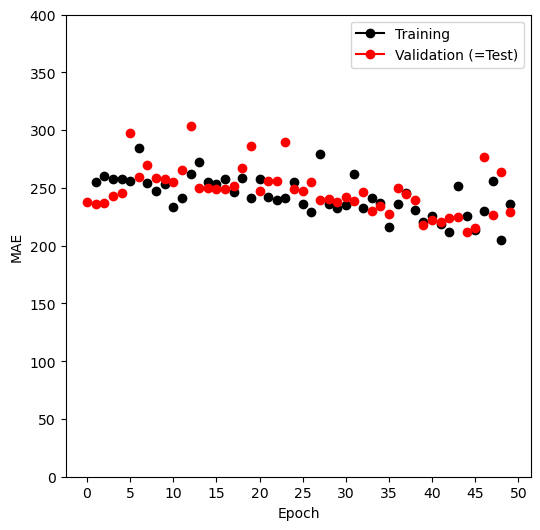

In [31]:
hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)

fig, ax = subplots(1,1, figsize=(6,6))
ax = summary_plot(hit_results,
                 ax,
                 col="mae",
                 ylabel="MAE",
                 valid_legend="Validation (=Test)")
ax.set_ylim([0, 400])
ax.set_xticks(np.linspace(0, 50, 11).astype(int))

##### We can solve this problem without relying on the ISLP wrappers

In [32]:
class HittersModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(input_size, 50),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        x = self.flatten(x)
        return torch.flatten(self.sequential(x))


##### Wrap it in a LightiningModule: This adds training, validation, test and optimizer logic

In [33]:
class HittersLightningModule(LightningModule):
    def __init__(self, input_size, lr=0.01):
        super().__init__()
        self.model = HittersModel(input_size)
        self.loss_fn = nn.MSELoss()
        self.mae = MeanAbsoluteError()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self(X)
        loss = self.loss_fn(y_hat, y)
        mae = self.mae(y_hat, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_mae", mae, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self(X)
        loss = self.loss_fn(y_hat, y)
        mae = self.mae(y_hat, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_mae", mae, prog_bar=True)
        return loss
    def test_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self(X)
        test_loss = self.loss_fn(y_hat, y)
        test_mae = self.mae(y_hat, y)
        self.log("test_loss", test_loss, prog_bar=True)
        self.log("test_mae", test_mae, prog_bar=True)    

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [34]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### prepare the data 
X = Hitters.drop("Salary", axis=1)
Y = Hitters["Salary"]
Y = Y.fillna(Y.mean())
X = pd.get_dummies(X, drop_first=True)
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)
Y_scaled = y_scaler.fit_transform(Y.values.reshape(-1,1)).flatten()
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_scaled, test_size=1/3, random_state=1)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32)

train_loader= DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=True, num_workers=0, worker_init_fn=lambda x: np.random.seed(0))
test_loader = DataLoader(TensorDataset(X_test_t, Y_test_t), batch_size=32)

#logging setup
hit_logger = CSVLogger("lightning_logs", name="hitters_model")

#Define the trainer and fit
hit_trainer = Trainer(deterministic=True,
                     max_epochs=50,
                     log_every_n_steps=5,
                     logger= hit_logger)
model = HittersLightningModule(input_size=X.shape[1], lr=0.01)
hit_trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=test_loader)
                        

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | HittersModel      | 1.1 K  | train
1 | loss_fn | MSELoss           | 0      | train
2 | mae     | MeanAbsoluteError | 0      | train
------------------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 77.25it/s, v_num=27, train_loss=0.394, train_mae=0.562, val_loss=0.388, val_mae=0.412] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 69.92it/s, v_num=27, train_loss=0.394, train_mae=0.562, val_loss=0.388, val_mae=0.412]


In [35]:
hit_trainer.test(model, dataloaders=test_loader)

c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 63.43it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.38754338026046753
        test_mae            0.4120793640613556
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.38754338026046753, 'test_mae': 0.4120793640613556}]

In [37]:
#inverse-transform to the original salary units
#y_scaler= StandardScaler()
y_scaled= y_scaler.fit_transform(Y.values.reshape(-1,1))
model.eval()
#with torch.no_grad(): # disables gradient tracking for speed and safety
    #preds = model(X_test_t).detach().numpy().reshape(-1,1)
preds = model(X_test_t).detach().numpy().reshape(-1,1)
preds_unscaled = y_scaler.inverse_transform(preds)
Y_test_unscaled = y_scaler.inverse_transform(Y_test_t.numpy().reshape(-1,1))
mae_unscaled = np.mean(np.abs(preds_unscaled - Y_test_unscaled))
print("Test MAE in salary units:",mae_unscaled)

Test MAE in salary units: 185.54295


##### Since we will produce similar plots in later examples, we write a simple generic function to produce this plot.

In [38]:
def summary_plot(results,
                ax,
                col="loss",
                valid_legend="Validation",
                training_legend="Training",
                ylabel="Loss",
                fontsize=20):
    for (column, color, label) in zip([f"train_{col}",
                                       f"val_{col}"],
                                      ["black",
                                      "red"],
                                      [training_legend,
                                      valid_legend]):
        results.plot(x="epoch",
                    y=column,
                    label=label,
                    marker="o",
                    color=color,
                    ax=ax)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    return ax


##### We now set up our axes and use our function to produce the MAE plot

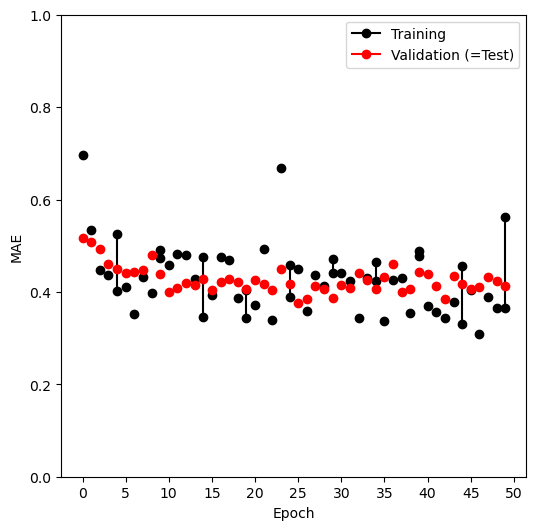

In [39]:
hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)

fig, ax = subplots(1,1, figsize=(6,6))
ax = summary_plot(hit_results,
                 ax,
                 col="mae",
                 ylabel="MAE",
                 valid_legend="Validation (=Test)")
ax.set_ylim([0, 1])
ax.set_xticks(np.linspace(0, 50, 11).astype(int))

In [40]:
hit_results.columns

Index(['epoch', 'step', 'test_loss', 'test_mae', 'train_loss', 'train_mae',
       'val_loss', 'val_mae'],
      dtype='object')

In [41]:
hit_results[["train_mae", "val_mae"]].describe()

,train_mae,val_mae
count,60.000000,50.000000
mean,0.428222,0.426548
std,0.073562,0.029151
min,0.309838,0.376121
25%,0.371180,0.407689
50%,0.426848,0.419880
75%,0.470097,0.440889
max,0.696006,0.517722


##### We can predict directly from the final model, and evaluate its performance on the test data. Before fitting, we call the **eval()** method of hit_model. This tells torch to effectively consider this model to be fitted, so that we can use it to predict on new data. For our model here, the biggest change is that the dropout layers will be turned off i.e no weights will be randomly dropped in predicting on new data.

In [42]:
hit_model.eval()
preds = hit_module(X_test_t)
torch.abs(Y_test_t - preds).mean()

tensor(11.0614, grad_fn=<MeanBackward0>)

#### Cleanup

##### In setting up our data module, we had initiated worker processes that will remain running. We delete all references to the torch objects to ensure these processes will be killed.

In [43]:
del(Hitters,
   hit_model, hit_dm,
   hit_logger,
   hit_test, hit_train,
   X, Y,
   X_test, X_train,
   Y_test, Y_train,
   X_test_t, Y_test_t,
   hit_trainer, hit_module)

#### Multilayer Network on the MNIST Digit Data

##### The torchvision package comes with a number of example datasets, including the MNIST digit data. Our first step is to retrieve the training and test data sets; the MNIST() function within torchvision.datasets is provided for this purpose. The data will be downloaded the first time this function is executed, and stored in the directory data/MNIST.

In [44]:
mnist_train, mnist_test = [MNIST(root="data",
                                train=train,
                                download=True,
                                transform=ToTensor()) for train in [True, False]] # this loops twice, first with train=True and then train=False(test split)
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

##### We form a data module from the training and test datasets, setting aside 20% of the training images for validation.

In [45]:
mnist_dm = SimpleDataModule(mnist_train,
                           mnist_test,
                           validation=0.2,
                           num_workers=max_num_workers,
                           batch_size=256)

##### Lets take a look at the data that will get fed into our network. We loop through the first few chunks of the test dataset, breaking after 2 batches.

In [47]:
for idx, (X_, Y_) in enumerate(mnist_dm.train_dataloader()):
    print("X:", X_.shape)
    print("Y:", Y_.shape)
    if idx >= 1:
        break

X: torch.Size([256, 1, 28, 28])
Y: torch.Size([256])
X: torch.Size([256, 1, 28, 28])
Y: torch.Size([256])


##### Lets recreate it manually without the SimpleDataModule.

In [48]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [60]:
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

#Split mnist_train into train/validation
#compute sizes
total_size = len(mnist_train)
val_size= int(0.2 * total_size)
train_size = total_size - val_size
#split
mnist_train_subset, mnist_val_subset = random_split(mnist_train, [train_size, val_size])

#create DataLoaders manually
batch_size = 256
num_workers = max_num_workers
train_loader = DataLoader(mnist_train_subset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=num_workers)
val_loader = DataLoader(mnist_val_subset, batch_size=batch_size, shuffle=False, persistent_workers=True, num_workers=num_workers)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [61]:
#Iterate through the train DataLoader
for idx, (X_, Y_) in enumerate(train_loader):
    print("X:", X_.shape)
    print("Y:", Y_.shape)
    if idx >= 1:
        break

X: torch.Size([256, 1, 28, 28])
Y: torch.Size([256])
X: torch.Size([256, 1, 28, 28])
Y: torch.Size([256])


##### We see that the X for each batch consists of 256 images of size 1x28x28. Here the 1 indicates a single channel(greyscale). For RGB images such as CIFAR100, we will see that the 1 in the size will be replaced by 3 for the RGB channels.

##### We are now ready to specify our neural network.

In [62]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.4))
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3))
        self._forward = nn.Sequential(
            self.layer1,
            self.layer2,
            nn.Linear(128, 10))
    def forward(self, x):
        return self._forward(x)
               

##### We see that in the first layer, each 1x28x28 image is flattened, then mapped to 256 dimensions where we apply a ReLU activation with 40% dropout. A second layer map the first layer's output down to 128 dimensions, applying a ReLU activation with 30% dropout. Finally, the 128 dimensions are mapped down to 10, the number of classes in the MNIST data.

In [63]:
mnist_model = MNISTModel()

##### We can check that the model produces output of expected size based on our existing batch X_ above.

In [64]:
mnist_model(X_).size()

torch.Size([256, 10])

##### Lets take a look at the summary of the model. Instead of an input_size we can pass a tensor of the correct shape. In this case, we pass through the final batch X_ from above.

In [55]:
summary(mnist_model,
       input_data=X_,
       col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTModel                               [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 10]                 --
│    └─Sequential: 2-1                   [256, 1, 28, 28]          [256, 256]                --
│    │    └─Flatten: 3-1                 [256, 1, 28, 28]          [256, 784]                --
│    │    └─Linear: 3-2                  [256, 784]                [256, 256]                200,960
│    │    └─ReLU: 3-3                    [256, 256]                [256, 256]                --
│    │    └─Dropout: 3-4                 [256, 256]                [256, 256]                --
│    └─Sequential: 2-2                   [256, 256]                [256, 128]                --
│    │    └─Linear: 3-5                  [256, 256]                [256, 128]                32,896
│    │    └─ReLU: 3-6     

##### Having set both the model and the data module, fitting this model is now almost identical to the Hitters example. In contrast to our regression model, here we will use the **SimpleModule.classification()** method which uses the cross-entropy loss function instead of the mean squared error.

In [56]:
mnist_module = SimpleModule.classification(mnist_model, num_classes=10)
mnist_logger = CSVLogger("logs", name="MNIST")

##### The final step is to supply the training data and fit the model.

In [57]:
mnist_trainer = Trainer(deterministic=True,
                       max_epochs=30,
                       logger=mnist_logger,
                       callbacks=[ErrorTracker()])
mnist_trainer.fit(mnist_module, datamodule=mnist_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MNISTModel       | 235 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
235 K     Trainable params
0         Non-trainable params
235 K     Total params
0.941     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 29: 100%|██████████| 188/188 [00:03<00:00, 55.51it/s, v_num=13]       

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:03<00:00, 55.20it/s, v_num=13]


##### Let us use the LightningModule: Define the model + Training Logic

In [67]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.4))
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3))
        self._forward = nn.Sequential(
            self.layer1,
            self.layer2,
            nn.Linear(128, 10))
    def forward(self, x):
        return self._forward(x)
        
class MNISTLitModel(LightningModule):
    def __init__(self,lr=1e-3):
        super().__init__()
        self.model = MNISTModel() #compose your base model
        self.lr=lr
        self.criterion= nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        X, y= batch
        preds= self(X)
        loss= self.criterion(preds, y)

        #manually compute accuracy
        acc= (preds.argmax(dim=1)==y).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        preds= self(X)
        loss = self.criterion(preds, y)
        acc= (preds.argmax(dim=1)==y).float().mean()
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        X, y = batch
        preds= self(X)
        loss = self.criterion(preds, y)
        acc= (preds.argmax(dim=1)==y).float().mean() #computes the classification accuracy(the fraction of correct)
        self.log("test_loss", loss)
        self.log("test_acc", acc)
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
        

In [68]:
#Train using Trainer
logger = CSVLogger("logs", name="MNIST")
trainer = Trainer(
    max_epochs=30,
    deterministic=True,
    logger=logger,
)
model = MNISTLitModel(lr=1e-3)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | MNISTModel       | 235 K  | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
235 K     Trainable params
0         Non-trainable params
235 K     Total params
0.941     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 29: 100%|██████████| 188/188 [00:04<00:00, 40.54it/s, v_num=15]      

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:04<00:00, 40.34it/s, v_num=15]


In [69]:
model = MNISTLitModel()
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
print(model)


235146
MNISTLitModel(
  (model): MNISTModel(
    (layer1): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
    )
    (layer2): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
    (_forward): Sequential(
      (0): Sequential(
        (0): Flatten(start_dim=1, end_dim=-1)
        (1): Linear(in_features=784, out_features=256, bias=True)
        (2): ReLU()
        (3): Dropout(p=0.4, inplace=False)
      )
      (1): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
      )
      (2): Linear(in_features=128, out_features=10, bias=True)
    )
  )
  (criterion): CrossEntropyLoss()
)


##### SimpleModule.classification() includes an accuracy metric by default. Other classification metrics can be added from **torchmetrics**. We will use our **summary_plot()** function to display accuracy across epochs.

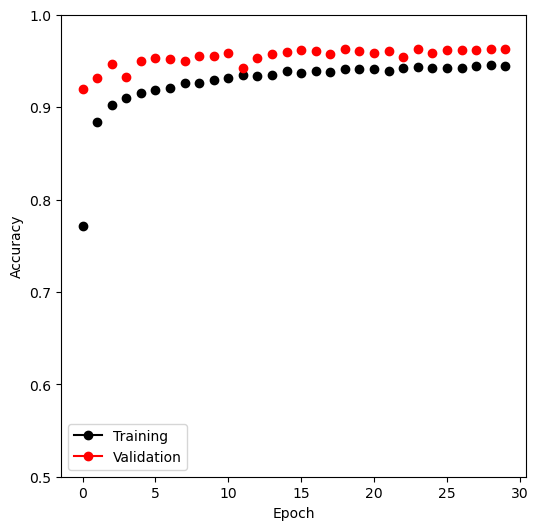

In [70]:
def summary_plot(results,
                ax,
                col="loss",
                valid_legend="Validation",
                training_legend="Training",
                ylabel="Loss",
                fontsize=20):
    for (column, color, label) in zip([f"train_{col}_epoch",
                                       f"valid_{col}"],
                                      ["black",
                                      "red"],
                                      [training_legend,
                                      valid_legend]):
        results.plot(x="epoch",
                    y=column,
                    label=label,
                    marker="o",
                    color=color,
                    ax=ax)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    return ax

mnist_results = pd.read_csv(mnist_logger.experiment.metrics_file_path)
fig, ax = subplots(1, 1, figsize=(6,6))
summary_plot(mnist_results, 
            ax,
            col="accuracy",
            ylabel="Accuracy")
ax.set_ylim([0.5, 1])
ax.set_ylabel("Accuracy")
ax.set_xticks(np.linspace(0, 30, 7).astype(int))

In [71]:
mnist_results.columns

Index(['epoch', 'step', 'train_accuracy_epoch', 'train_accuracy_step',
       'train_loss', 'valid_accuracy', 'valid_loss'],
      dtype='object')

##### Once again we evaluate the accuracy using the **test()** method of our trainer. This model achieves 97% accuracy on the test data.

In [72]:
mnist_trainer.test(mnist_module, datamodule=mnist_dm)

Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 69.65it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9616000056266785
        test_loss           0.1532212346792221
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.1532212346792221, 'test_accuracy': 0.9616000056266785}]

#### Multiclass Logistic Regression

##### Although we could use the sklearn function LogisticRegression() to fit multiclass logistic regression, we are set up here to fit such a model with torch. We just have an input layer and an output layer, and omit the hidden layers.

In [73]:
class MNIST_MLR(nn.Module):
    def __init__(self):
        super(MNIST_MLR, self).__init__()
        self.linear = nn.Sequential(nn.Flatten(),
                                   nn.Linear(784, 10))
    def forward(self, x):
            return self.linear(x)
            
mlr_model = MNIST_MLR()
mlr_module = SimpleModule.classification(mlr_model, num_classes=10)
mlr_logger = CSVLogger("logs", name= "MNIST_MLR")
mlr_trainer = Trainer(deterministic=True,
                     max_epochs=30,
                     callbacks=[ErrorTracker()])
mlr_trainer.fit(mlr_module, datamodule=mnist_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MNIST_MLR        | 7.9 K  | train


Epoch 29: 100%|██████████| 188/188 [00:02<00:00, 64.30it/s, v_num=3]        

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:02<00:00, 63.97it/s, v_num=3]


##### We have just fit the model as before and we can compute the test results.

In [74]:
mlr_trainer.test(mlr_module, datamodule=mnist_dm)

Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 47.55it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9125999808311462
        test_loss           0.3651764690876007
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.3651764690876007, 'test_accuracy': 0.9125999808311462}]

##### The accuracy is above 90% even for this pretty simple model.

##### As in the Hitters example, we delete some of the objects we created above.

In [75]:
del(mnist_test, mnist_train, mnist_model, mnist_dm, mnist_trainer, mnist_module, mnist_results, mlr_model, mlr_module, mlr_trainer)

#### Convolutional Neural Networks

##### In this section we fit a CNN to the **CIFAR100** data, which is available in the torchvision package. It is arranged in a similar fashion as the MNIST data.

In [105]:
# Load the dataset and obtain train and test data
(cifar_train_raw, cifar_test_raw) = [CIFAR100(root="data",
                                     train=train,
                                     download=True) for train in [True, False]]

Files already downloaded and verified
Files already downloaded and verified


In [106]:
#First, keep the original datasets in separate variables
transform = ToTensor()

#Use the original dataset objects for accessing .data and .targets
#Now transform the data
cifar_train_X = torch.stack([transform(x) for x in cifar_train_raw.data])

cifar_test_X = torch.stack([transform(x) for x in cifar_test_raw.data])

cifar_train = TensorDataset(cifar_train_X, torch.tensor(cifar_train_raw.targets))

cifar_test = TensorDataset(cifar_test_X, torch.tensor(cifar_test_raw.targets))

##### The **CIFAR100** dataset consists of 50,000 training images, each represented by a 3-D tensor: each three-color image is represented as a set of three channels, each of which consists of 32 x 32 eight-bit pixels. We standardize as we did for the digits, but keep the array structure. This is accomplished with the **ToTensor()** transform.

In [107]:
#creating the data module is similar to the MNIST example
cifar_dm = SimpleDataModule(cifar_train,
                           cifar_test,
                           validation=0.2,
                           num_workers=max_num_workers,
                           batch_size=128)

##### We again look at the shape of typical batches in our data loaders.

In [108]:
for idx, (X_, Y_) in enumerate(cifar_dm.train_dataloader()):
    print("X:", X_.shape)
    print("Y:", Y_.shape)
    if idx >= 1:
        break

X: torch.Size([128, 3, 32, 32])
Y: torch.Size([128])
X: torch.Size([128, 3, 32, 32])
Y: torch.Size([128])


##### Below is an illustration that **TensorDataset** objects can be indexed with integers; we are choosing random images from the training data by indexing cifar_train. In order to display correctly, we must reorder the dimensions by a call to np.transpose().

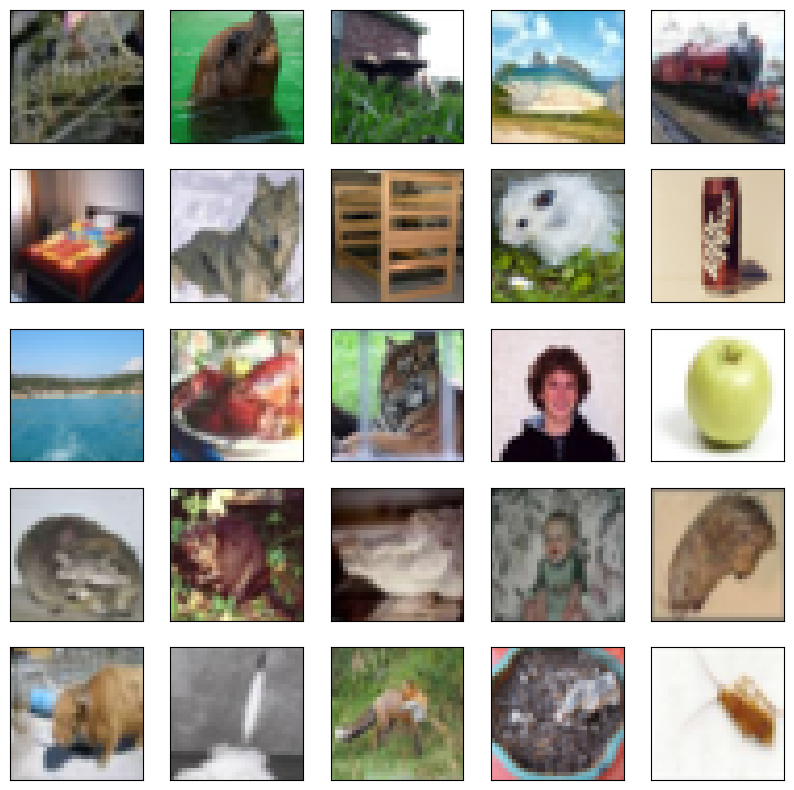

In [109]:
fig, axes = subplots(5, 5, figsize=(10, 10))
rng = np.random.default_rng(4) #creates a random number generator with seed 4 for reproducibility

#randomly select 25 unique indices from the dataset and reshape those 25 indices into a 5x5 grid so each subplot gets one index
indices = rng.choice(np.arange(len(cifar_train)), 25, replace=False).reshape((5,5))

#Double loop to iterate over each subplot coordinate(row:i, column:j) 
for i in range(5):
    for j in range(5):
        idx = indices[i, j] #retrieves the dataset index for the subplot
        #cifar_train[idx] returns a tuple(image_tensor, label), cifar_train[idx][0] selects the image tensor(shape[C,H,W]), np.transpose(..,[1,2,0]) reorders tensor dimensions to [H,W,C], since imshow() expects channel last
        axes[i, j].imshow(np.transpose(cifar_train[idx][0], [1,2,0]), interpolation=None)

        #Remove the tick marks and labels on both x and y axes for a cleaner look
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

##### For demonstration purposes, we specifiy a moderately sized CNN. We use several layers, each consisting of convolution, ReLU, and max-pooling steps. We first define a module that defines one of these layers.  

In [110]:
class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels):

        super(BuildingBlock, self).__init__() #calls the parent(nn.Module) initializer to properly set up PyTorch internals
        self.conv = nn.Conv2d(in_channels=in_channels, #number of input feature channels(e.g 3 for RGB images)
                             out_channels=out_channels, #number of filters to produce
                             kernel_size=(3,3), #size of the filter
                             padding="same") # keeps the output's height and width equal to the input's
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2,2))
    def forward(self, x):
        return self.pool(self.activation(self.conv(x)))

##### In forming our deep learning model for the CIFAR100 data, we use several of our **BuildingBlock()** modules sequentially. This simple example illustrates some of the power of torch. Users can define modules of their own, which can be downloaded in other modules. Ultimately, everything is fit by a generic trainer.

In [111]:
class CIFARModel(nn.Module):
    def __init__(self):
        super(CIFARModel, self).__init__()
        sizes= [(3, 32), #defines a list of channel transitions for the convolutional layers
              (32, 64),  # Each pair(in_channels, out_channels) describes one BuildingBlock which performs Conv2D → ReLU → MaxPool2D 
              (64, 128),
              (128, 256)]
        self.conv =nn.Sequential(*[BuildingBlock(in_, out_) for in_, out_ in sizes])
        self.output = nn.Sequential(nn.Dropout(0.5),
                                   nn.Linear(2*2*256, 512),
                                   nn.ReLU(),
                                   nn.Linear(512, 100))
    def forward(self, x):
        val= self.conv(x)
        val = torch.flatten(val, start_dim=1)
        return self.output(val)

#unpacking the code
#The list comprehension creates 4 BuildingBlock instances from the sizes list.
# The * unpacks the list so that nn.Squential receives each block as  a separate argument.
#The self.conv is a single module containing the full convolutional feature extractor.
# Each block downsamples the image by half, so after 4 blocks, the spatial size reduces from: 32×32 → 16×16 → 8×8 → 4×4 → 2×2
#Thus the feature maps end up being of shape [batch_size, 256, 2, 2]

##### We build the model and look at the summary

In [112]:
cifar_model = CIFARModel()
summary(cifar_model,
       input_data=X_,
       col_names= ["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CIFARModel                               [128, 3, 32, 32]          [128, 100]                --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 256, 2, 2]          --
│    └─BuildingBlock: 2-1                [128, 3, 32, 32]          [128, 32, 16, 16]         --
│    │    └─Conv2d: 3-1                  [128, 3, 32, 32]          [128, 32, 32, 32]         896
│    │    └─ReLU: 3-2                    [128, 32, 32, 32]         [128, 32, 32, 32]         --
│    │    └─MaxPool2d: 3-3               [128, 32, 32, 32]         [128, 32, 16, 16]         --
│    └─BuildingBlock: 2-2                [128, 32, 16, 16]         [128, 64, 8, 8]           --
│    │    └─Conv2d: 3-4                  [128, 32, 16, 16]         [128, 64, 16, 16]         18,496
│    │    └─ReLU: 3-5                    [128, 64, 16, 16]         [128, 64, 16, 16]         --
│    │    └─MaxPool2d: 3-6    

##### Up to now, we have been using a default optimizer in SimpleModule(). For these data, experiments show that a smaller learning rate performs better than the deafult 0.01. We use a custom optimizer here with a leraning rate of 0.001. Besides this, the logging and training follow a similar pattern to the previous examples. 
##### The optimizer takes an argument params that informs the optimizer which parameters are involved in SGD.

In [115]:
cifar_optimizer = RMSprop(cifar_model.parameters(), lr=0.001)
cifar_module = SimpleModule.classification(cifar_model, optimizer=cifar_optimizer, num_classes=100)
cifar_logger = CSVLogger("logs", name="CIFAR100")

In [116]:
cifar_trainer = Trainer(deterministic=True,
                       max_epochs=30,
                       logger=cifar_logger,
                       callbacks=[ErrorTracker()])
cifar_trainer.fit(cifar_module, datamodule=cifar_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | CIFARModel       | 964 K  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
964 K     Trainable params
0         Non-trainable params
964 K     Total params
3.858     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Epoch 29: 100%|██████████| 313/313 [00:47<00:00,  6.63it/s, v_num=4]        

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 313/313 [00:47<00:00,  6.63it/s, v_num=4]


##### Lets take a look at the validation and training accuracy across epochs.

(0.0, 1.0)

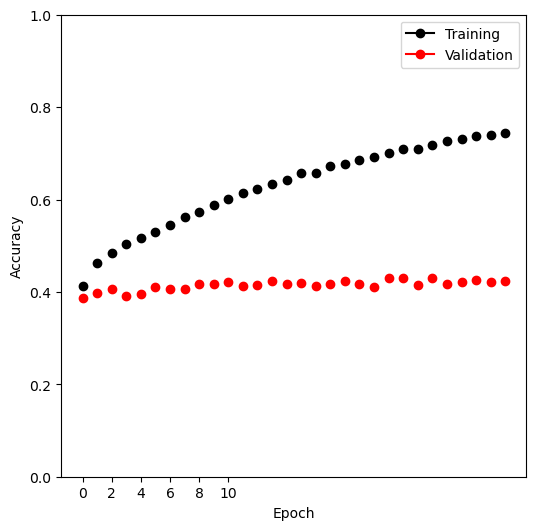

In [117]:
log_path = cifar_logger.experiment.metrics_file_path
cifar_results = pd.read_csv(log_path)

fig, ax = subplots(1, 1, figsize=(6,6))
summary_plot(cifar_results,
            ax,
            col="accuracy",
            ylabel="Accuracy")
ax.set_xticks(np.linspace(0, 10, 6).astype(int))
ax.set_ylabel("Accuracy")
ax.set_ylim([0, 1])

##### Finally we evaluate our model on our test data

In [118]:
cifar_trainer.test(cifar_module, datamodule=cifar_dm)

Testing DataLoader 0: 100%|██████████| 79/79 [00:04<00:00, 17.63it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.42640000581741333
        test_loss           2.7171783447265625
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.7171783447265625, 'test_accuracy': 0.42640000581741333}]

#### Hardware Acceleration

##### As deep learning has become ubiquitous in machine learning, hardware manufacturers have produced special libraries that can often speed up the gradient-descent steps. For instance, Mac OS devices with the M1 chip may have the Metal programming framework enabled, which can speed up the torch computations.
##### The main changes are to the **Trainer()** call as well as to the metrics that will be evaluated on the data. These metrics must be told where the data will be located at evaluation time. This is accomplished with a call to the **to()** method of the metrics.

In [ ]:
try:
    for name, metric in cifar_module.metrics.items():
        cifar_module.metrics[name] = metric.to("mps")
    cifar_trainer_mps = Trainer(accelerator="mps",
                               deterministic=True,
                               max_epochs=30)
    cifar_trainer_mps.fit(cifar_module, datamodule=cifar_dm)
    cifar_trainer_mps.test(cifar_module, datamodule=cifar_dm)
except:
    pass

#This yields approximately two or three fold acceleration for each epoch. The try and except block clauses; if it works, we get the speedup, if it fails nothing happens

#### Using Pretrained CNN Models
##### We now show how to use a CNN pretrained on the **imagenet** database to classify natural images. We copied six JPEG images from a digital photo album into the directory book_images. 
##### The pretrained network we use is called **resnet50**. We will read in the images, and convert them into the array format expected by the torch software to match the specifications in resnet50. 
##### The conversion involves a resize, a crop and then a predefined standardization for each of the three channels.


In [88]:
# We now read in the images and preprocess them.
import os

resize = Resize((232, 232))
crop = CenterCrop(224)
normalize = Normalize([0.485, 0.456, 0.406], #Normalizes image pixel values channel-wise using the mean and std of ImageNet data
                     [0.229, 0.224, 0.225])
image_dir = "C:\\Users\\colli\\OneDrive\\Desktop\\book_images"
imgfiles = sorted([f for f in glob(os.path.join(image_dir, "*.jpg"))])
imgs = torch.stack([torch.div(crop(resize(read_image(f))), 255) for f in imgfiles]) #torch.div(..., 255) scales pixels to [0,1], read_image(f) loads each image file as a tensor[C,H,W]
imgs = normalize(imgs)
imgs.size()

# read_image loads tensors as uint8 by default, so we scale to [0,1] by dividing by 255 before normalizing
#imgs=[]
#for f in imgfiles:
 #   img = read_image(f).float() / 255. # read → float tensor → normalize
  #  img = crop(resize(img))
   # imgs.append(img)

#batch = torch.stack(imgs)    

torch.Size([6, 3, 224, 224])

##### We now set up the trained network with the weights ResNet50_Weights. The model has 50 layers, with a fair bit of complexity.

In [89]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
summary(resnet_model,
       input_data=imgs,
       col_names=["input_size",
                 "output_size",
                 "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [6, 3, 224, 224]          [6, 1000]                 --
├─Conv2d: 1-1                            [6, 3, 224, 224]          [6, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [6, 64, 112, 112]         [6, 64, 112, 112]         128
├─ReLU: 1-3                              [6, 64, 112, 112]         [6, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [6, 64, 112, 112]         [6, 64, 56, 56]           --
├─Sequential: 1-5                        [6, 64, 56, 56]           [6, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [6, 64, 56, 56]           [6, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [6, 64, 56, 56]           [6, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [6, 64, 56, 56]           [6, 64, 56, 56]           128
│    │    └─ReLU: 3-3      

##### We set the model to **eval()** to ensure that the model is ready to predict on new data.

In [90]:
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

##### Inspect the output above, we see that when setting up the resnet_model, the authors defined a **Bottleneck**, much like the **BuildingBlock** module.

In [91]:
# We now feed our six images through the fitted network

img_preds= resnet_model(imgs)

##### Lets look at the predicted probabilities for each of the top 3 choices. First we compute the probabilities by applying the softmax to the logits in img_preds.
##### Note that we call the **detach()** method on the tensor img_preds in order to convert it to a more familiar **ndarray**

In [92]:
#img_probs = np.exp(np.asarray(img_preds.detach()))
#img_probs /= img_probs.sum(1)[:, None]
#img_probs

#or
img_preds = img_preds.detach().numpy()
exp_preds = np.exp(img_preds)
img_probs = exp_preds / np.sum(exp_preds, axis=1, keepdims=True) #softmax
img_probs


array([[0.00049329, 0.00081996, 0.00033158, ..., 0.00037007, 0.00065362,
        0.00035974],
       [0.00028439, 0.0004149 , 0.00040286, ..., 0.00033107, 0.00041182,
        0.00042838],
       [0.00045656, 0.00064541, 0.00049665, ..., 0.00054565, 0.00044345,
        0.00051163],
       [0.00044781, 0.00054025, 0.00037828, ..., 0.00032235, 0.00042586,
        0.0004845 ],
       [0.00040326, 0.00044377, 0.00065879, ..., 0.0003874 , 0.00051848,
        0.00062297],
       [0.00049051, 0.00038088, 0.0006056 , ..., 0.00044883, 0.00143834,
        0.00426437]], shape=(6, 1000), dtype=float32)

##### In order to see the class labels, we must download the index file associated with the **imagenet**

In [93]:
labs = json.load(open("C:\\Users\\colli\\OneDrive\\Desktop\\ISLP\\imagenet_class_index.json"))
class_labels = pd.DataFrame([(int(k), v[1]) for k, v in labs.items()],
                           columns=["idx", "label"])
class_labels = class_labels.set_index("idx")
class_labels = class_labels.sort_index()

##### We will now construct a data frame for each image file with the labels with the three highest probabilities as estimated by the model above.

In [94]:
for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df["prob"] = img_probs[i]
    img_df = img_df.sort_values(by="prob", ascending=False)[:3]
    print(f"Image: {imgfile}")
    print(img_df.reset_index().drop(columns=["idx"]))

Image: C:\Users\colli\OneDrive\Desktop\book_images\Cape_Weaver.jpg
      label      prob
0   jacamar  0.297500
1     macaw  0.068107
2  lorikeet  0.051104
Image: C:\Users\colli\OneDrive\Desktop\book_images\Flamingo.jpg
            label      prob
0        flamingo  0.609514
1       spoonbill  0.013586
2  American_egret  0.002132
Image: C:\Users\colli\OneDrive\Desktop\book_images\Hawk_Fountain.jpg
            label      prob
0            kite  0.184717
1           robin  0.084018
2  great_grey_owl  0.061267
Image: C:\Users\colli\OneDrive\Desktop\book_images\Hawk_cropped.jpg
            label      prob
0            kite  0.453834
1  great_grey_owl  0.015914
2             jay  0.012210
Image: C:\Users\colli\OneDrive\Desktop\book_images\Lhasa_Apso.jpg
             label      prob
0            Lhasa  0.260316
1         Shih-Tzu  0.097196
2  Tibetan_terrier  0.032820
Image: C:\Users\colli\OneDrive\Desktop\book_images\Sleeping_Cat.jpg
         label      prob
0  Persian_cat  0.163069
1       

##### We see that the model is quite confident about **Flaming.jpg**, but a little less do for the other things.

##### We end this session with our usual cleanup

In [95]:
del(cifar_test, cifar_train, cifar_dm, cifar_module, cifar_logger, cifar_optimizer, cifar_trainer)

#### IMDB Document Classification

##### We now implement models for sentiment classification on the **IMDB** dataset. As mentioned earlier we are using a preprocessed version of the IMDB dataset found in the **keras** package. As **keras** uses **tensorflow**, a different tensor and deep learning library, the data was converted to be suitable for torch. The code used to convert from keras is available in the module **ISLP.torch._make_imdb**. It requires some of the keras packages to run. These data use a dictionary of size 10,000.
#####  We have stored three different representations of the review data for this lab:
##### **load_tensor()**, a sparse tensor version usable by **torch**. --Use case: for PyTorch neural networks that can handle bag-of-words input efficiently.
##### **load_sparse()**, a sparse matrix version usable by **sklearn**, since we will compare with a lasso fit. -- Use case: for classical ML models like logistic regression, lasso SVM etc. implemented in scikit-learn.
##### **load_sequential()**, a padded version of the original sequence representation, limited to the last 500 words of each review. -- Use case: For models that process word order like **RNNs**, **LSTM**, or **CNNs** for text. Each review is stored as a sequence of integers(each representing a word ID) . Since reviews vary in length, they're padded or truncated to a fixed length.

In [11]:
(imdb_seq_train, imdb_seq_test) = load_sequential(root="data/IMDB")
padded_sample = np.asarray(imdb_seq_train.tensors[0][0])
sample_review = padded_sample[padded_sample > 0][:12]
sample_review[:12]

c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\ISLP\torch\imdb.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  S_test) = [torch.load(_get_imdb(f'IMDB_{r}', roo

array([   1,   14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458,
       4468], dtype=int32)

##### Let us do it in a Pure PyTorch Way

##### The code below does the following:
##### * Loads IMDB dataset locally
##### * Tokenizes the text
##### * Builds a vocabulary
##### * Converts each review into a sequence of word indices
##### * Pads/truncates each to 500 tokens

In [ ]:
#from torchtext.datasets import IMDB
#from torchtext.data.utils import get_tokenizer
#from torchtext.vocab import build_vocab_from_iterator
#from torch.nn.utils.rnn import pad_sequence

In [ ]:
## Load raw text data (train/test)
#train_iter, test_iter = IMDB(root="data")

## Tokenize (split into words)
#tokenizer = get_tokenizer("basic_english")

#def yield_tokens(data_iter):
 #   for label, text in data_iter:
  #      yield tokenizer(text)


## Build a vocabulary (top 10,000 most frequent words)
#vocab = build_vocab_from_iterator(yield_tokens(train_iter), specials=["<unk>"])
#vocab.set_default_index(vocab["<unk>"])

## Reinitialize iterators since they get exhausted
#train_iter, test_iter = IMDB(root="data")

## Convert each text into integer sequences
#def text_pipeline(text):
  #  return torch.tensor(vocab(tokenizer(text)), dtype=torch.long)
##
#def label_pipeline(label):
 #   return 1 if label == "pos" else 0

## Encode and pad reviews
#MAX_LEN = 500

#def process_batch(data_iter):
 #   X, y = [], []
  #  for label, text in data_iter:
   #     seq= text_pipeline(text)
    #    seq= seq[-MAX_LEN] #truncate last 500 words
     #   X.append(seq)
      #  y.append(torch.tensor(label_pipeline(label)))
    #pad to equal length
    #X = pad_sequence(X, batch_first=True)
    #y= torch.stack(y)
    #return X, y
    

In [ ]:
#X_train, y_train = process_batch(train_iter)
#X_test, y_test = process_batch(test_iter)
#print("Training data:", X_train.shape, y_train.shape)

##### Replacement for torchtext
##### Torchtext version issues: not compatible with other torch packages versions in this environment.
##### We therefore use HuggingFace datasets

In [9]:
dataset = load_dataset("imdb")
train_data= dataset["train"]
test_data= dataset["test"]  


In [10]:
# Replace get_tokenizer
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower()) #\b word boundary between a word char and a non-word char. \w+ matches one or more word characters (letters, digits, underscores). text.lower() converts text to lowercase.  

In [11]:
# Replace build_vocab_from_iterator
def build_vocab(data_iter, max_size=10000):
    counter = Counter() #counts the occurences of each word
    for item in data_iter:
        tokens = tokenize(item["text"])
        counter.update(tokens)
    most_common = counter.most_common(max_size - 2) #reserve 2 for <unk> and <pad>
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab["<unk>"] = 0
    vocab["<pad>"] = 1
    return vocab  
#vocab = build_vocab(train_data)  

In [12]:
#Convert tokens to integer IDs

def encode(text, vocab):
    return [vocab.get(token, 0) for token in tokenize(text)] # if the token exists in the vocab it returns its index and returns 0 if it does not.

In [13]:
#Custom PyTorch Dataset

class IMDBDataset(Dataset):
    def __init__(self, data, vocab): #load dataset + vocab
        self.data = data
        self.vocab = vocab

    def __getitem__(self, idx): #retrieve one item at index: Returns (text, label) tuple
        item = self.data[idx] #
        X = torch.tensor(encode(item["text"], self.vocab))
        y = torch.tensor(1 if item["label"] =="pos" else 0)
        return X, y

    def __len__(self): #return dataset size
        return len(self.data)    

In [14]:
#Padding sequences: We keep only the last 500 tokens from each review and pad shorter reviews with the <pad> token(index 1) to ensure all sequences in a batch have the same length.
MAX_LEN = 500

def collate_batch(batch):
    Xs, ys = zip(*batch) #unzips the batch into separate lists of inputs and labels
    
    #keep only last MAX_LEN tokens
    Xs = [x[-MAX_LEN:] for x in Xs]

    #pad sequences to same length
    Xs_padded = torch.nn.utils.rnn.pad_sequence(Xs, batch_first=True, padding_value=1) #pads sequences to equal length using <pad> token index 1
    ys = torch.stack(ys) #stacks labels into a single tensor
    return Xs_padded, ys  

In [ ]:
# Lets create DataLoaders for training and testing

vocab = build_vocab(train_data, max_size=10000 )

imdb_train_dataset = IMDBDataset(train_data, vocab)
imdb_test_dataset = IMDBDataset(test_data, vocab)

train_loader = DataLoader(imdb_train_dataset, batch_size=512, shuffle=True, collate_fn=collate_batch, num_workers=max_num_workers, persistent_workers=True)
test_loader = DataLoader(imdb_test_dataset, batch_size=512, shuffle=False, collate_fn=collate_batch, num_workers=max_num_workers, persistent_workers=True)   


In [ ]:
# Lets test it

batch = next(iter(train_loader))
X_batch, y_batch = batch        
#print("X batch shape:", X_batch.shape) #should be [batch_size, seq_length]
#print("y batch shape:", y_batch.shape) #should be [batch_size]

##### Let us integer IDs back to tokens

In [26]:
# We create a lookup dictionary

lookup= {idx: word for word, idx in vocab.items()}

#sample review from the dataset
sample_x, sample_y = imdb_train_dataset[0] #first review in the dataset

#decode only non-pad tokens

def decode(tokens, lookup):
    return " ".join(lookup.get(int(t), "<unk>") for t in tokens if t !=1)


print(decode(sample_x, lookup))


i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was <unk> by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself br br the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular she wants to focus her <unk> to making some sort of documentary on what the average <unk> thought about certain political issues such as the vietnam war and race issues in the united states in between asking politicians and ordinary <unk> of <unk> about their opinions on politics she has sex with her drama teacher classmates and married men br br what kills me about i am curious yellow is that 40 years ago this was considered pornographic really the sex and nudity scenes are few and far between even then it s not shot like some cheaply 

##### Let us now continue with the wrappers.

##### The datasets imdb_seq_train and imdb_seq_test are both instances of the class **TensorDataset**. The tensors used to contruct them can be found in the **tensors** attribute, with the first tensor the features X and the second the outcome Y. In the preprocessing used to form these data, sequences were paddded with 0s in the beginning if they were not long enough, hence we remove this padding by restricting to entries where **padded_sample>0**. We then provide the first 12 words of the sample review.

##### We can find these words in the lookup dictionary from the **ISLP.torch.imdb** module.

In [12]:
lookup = load_lookup(root="data/IMDB")
print(" ".join(lookup[i] for i in sample_review))

<START> this film was just brilliant casting location scenery story direction everyone's


##### For our first model, we have created a binary feature for each of the 10,000 possible words in the dataset, with an entry of one in the i, j entry if word j appears in review i. As most reviews are quite short, such a feature matrix has over 98% zeros.
##### These data are accessed using **load_tensor()** from the ISLP library.

In [13]:
max_num_workers = 10
imdb_train, imdb_test = load_tensor(root="data/IMDB")   
imdb_dm = SimpleDataModule(imdb_train, 
                           imdb_test,
                           batch_size=512,
                           num_workers=min(6, max_num_workers),
                           validation=2000 )

c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\ISLP\torch\imdb.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_test, X_train = [torch.load(_get_imdb(f'IMDB_{

##### We will use a two layer model for our first model

In [14]:
#class IMDBModel(nn.Module):
    #def __init__(self, input_size):
        #super(IMDBModel, self).__init__()
        #self.dense1 = nn.Linear(input_size, 16)
       # self.activation = nn.ReLU()
      #  self.dense2 = nn.Linear(16,16)
     #   self.output = nn.Linear(16,1)
    #def forward(self, x):
        #val = x
        #for _map in [self.dense1, self.activation, self.dense2, self.activation, self.output]:
         #   val = _map(val)
       #return torch.flatten(val)   

# Lets rewrite the model using nn.Sequential
class IMDBModel(nn.Module):
    def __init__(self, input_size):
        super(IMDBModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return torch.flatten(self.model(x)) 
        

##### We now instantiate our model and look at the summary

In [15]:
imdb_model = IMDBModel(imdb_test.tensors[0].size()[1])
summary(imdb_model,
       input_size=imdb_test.tensors[0].size(),
       col_names=["input_size", "output_size", "num_params"])       

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
IMDBModel                                [25000, 10003]            [25000]                   --
├─Sequential: 1-1                        [25000, 10003]            [25000, 1]                --
│    └─Linear: 2-1                       [25000, 10003]            [25000, 16]               160,064
│    └─ReLU: 2-2                         [25000, 16]               [25000, 16]               --
│    └─Linear: 2-3                       [25000, 16]               [25000, 16]               272
│    └─ReLU: 2-4                         [25000, 16]               [25000, 16]               --
│    └─Linear: 2-5                       [25000, 16]               [25000, 1]                17
Total params: 160,353
Trainable params: 160,353
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 4.01
Input size (MB): 1000.30
Forward/backward pass size (MB): 6.60
Params size (MB): 0.64
Estimated Total Size (M

##### We again use a smaller learning rate for these data, hence we pass an **optimizer** to the **SimpleModule**. Since the reviews are classified into positive or negative sentiment, we use **SimpleModule.binary_classification()**

In [16]:
imdb_optimizer = RMSprop(imdb_model.parameters(), lr=0.001) 
imdb_module = SimpleModule.binary_classification(imdb_model, optimizer=imdb_optimizer)  
imdb_logger = CSVLogger("logs", name="IMDB")    
imdb_trainer = Trainer(deterministic=True,
                       max_epochs=30,
                       logger=imdb_logger,
                       callbacks=[ErrorTracker()])  

imdb_trainer.fit (imdb_module, datamodule=imdb_dm)                       

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | IMDBModel         | 160 K  | train
1 | loss  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
160 K     Trainable params
0         Non-trainable params
160 K     Total params
0.641     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 29: 100%|██████████| 45/45 [00:01<00:00, 36.95it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 45/45 [00:01<00:00, 36.41it/s, v_num=1]


In [17]:
# Evaluating the test error yields roughly 86% accuracy
test_results= imdb_trainer.test(imdb_module, datamodule=imdb_dm) 
test_results 

Testing DataLoader 0: 100%|██████████| 49/49 [00:01<00:00, 34.48it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy          0.849839985370636
        test_loss           1.0897910594940186
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.0897910594940186, 'test_accuracy': 0.849839985370636}]

##### Comparison to Lasso

In [18]:
# We now fit a lasso logistic regression model using LogisticRegression() from sklearn. Since sklearn does not recognize the sparse tensors of torch, we use a sparse matrix that is recognized by sklearn
((X_train, Y_train),(X_valid, Y_valid),(X_test, Y_test))= load_sparse(validation=2000, random_state=0, root="data/IMDB")

# load_sparse() loads the IMDB review dataset in a sparse representation, that is instead of storing the entire feature matrix as a huge dense array, it stores it efficiently using SciPy's sparse matrix format.
# Each review is represented as a bag-of-words vector.
#Why sparse? ; Because if the vocabulary has 10,000 words, each review will be a vector of length 10,000, but most reviews will only contain a small subset of those words, leading to many zeros in the vector. Storing these vectors as dense arrays would waste memory and computational resources.

In [19]:
#We construct a series of 50 values for the lasso regularization parameter alpha ranging from 0.0001 to 1.0 on a logarithmic scale

lam_max = np.abs(X_train.T * (Y_train - Y_train.mean())).max() # measures the maximum absolute correlation between any feature and the centered target variable 
lam_val = lam_max * np.exp(np.linspace(np.log(1), np.log(1e4), 50)) # scales lam_max down to lam_max/1e4 in 50 logarithmically spaced steps

In [47]:
# With LogisticRegression() the regularization parameter C is specified as the inverse of alpha.
#There are several solvers for LR; here we use liblinear which supports L1 regularization
logit = LogisticRegression(penalty="l1",
                           C=1/lam_max,
                           solver="liblinear",
                           warm_start=True,
                           fit_intercept=True)

In [48]:
coefs =[]
intercepts=[]
for lam in lam_val:
    logit.C = 1/lam_max
    logit.fit(X_train, Y_train)
    coefs.append(logit.coef_.copy())
    intercepts.append(logit.intercept_)

In [49]:
#The coefficient and the intercept have an extraneous dimension which can be removed by np.squeeze() function

coefs = np.squeeze(coefs)
intercepts = np.squeeze(intercepts)   

(0.0, 1.0)

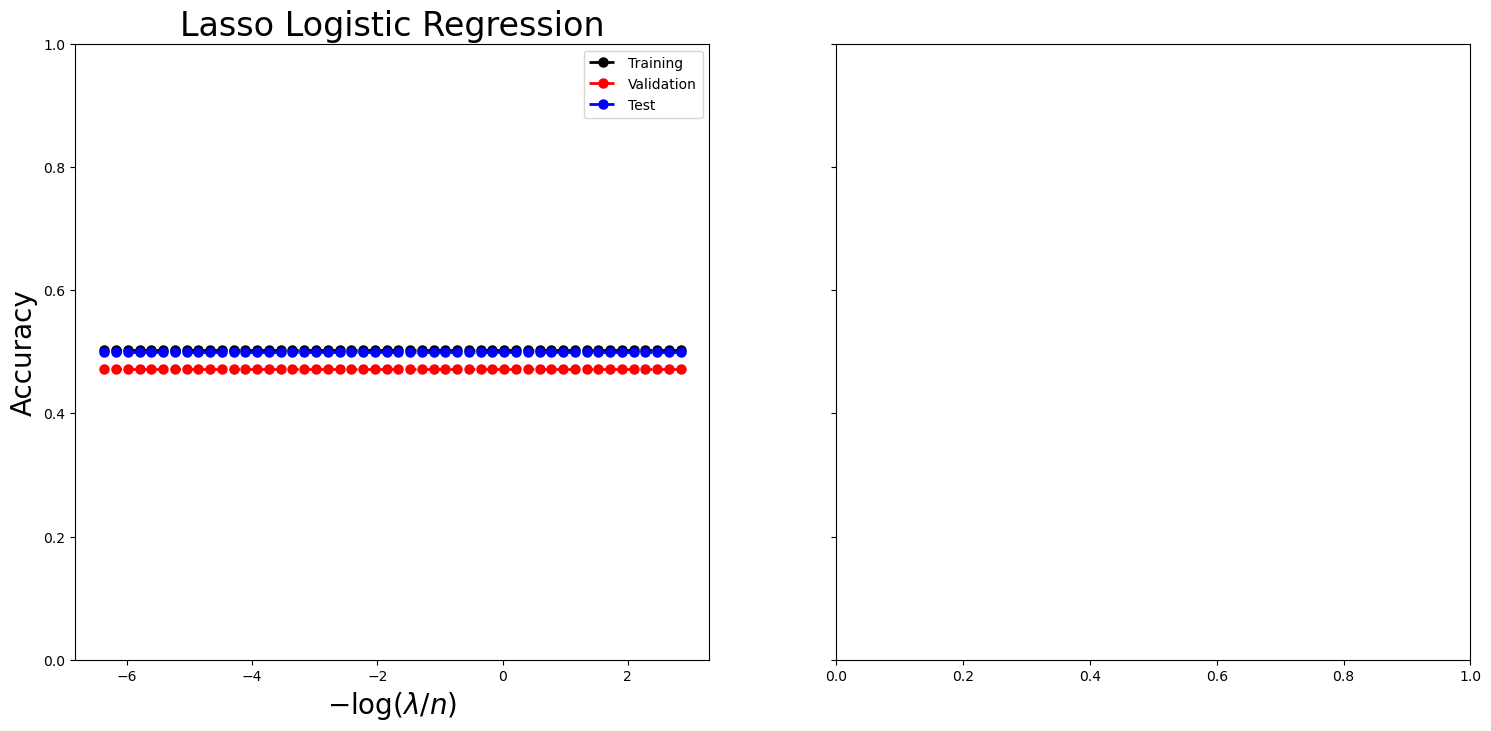

In [50]:
#We now make a plot to compare our neural network results with lasso.
#%%capture
fig, axes = subplots(1, 2, figsize=(18,8), sharey=True)
for ((X_, Y_), data_, color) in zip([(X_train, Y_train),(X_valid, Y_valid),(X_test, Y_test)],
                                   ["Training", "Validation", "Test"],
                                   ["black", "red", "blue"]):
    linpred_ = X_ * coefs.T + intercepts[None,:] #computes the linear predictor for each sample and each lambda value                               
    label_ = np.array(linpred_ > 0) #classify as positive if linear predictor > 0
    accuracy_ = np.array([np.mean(Y_ ==l) for l in label_.T]) #compute accuracy for each lambda value
    axes[0].plot(-np.log(lam_val / X_train.shape[0]), accuracy_,'.--',color=color, label=data_, markersize=13, linewidth=2)
axes[0].legend()
axes[0].set_xlabel(r"$-\log(\lambda/n)$", fontsize=20)
axes[0].set_ylabel("Accuracy", fontsize=20)
axes[0].set_title("Lasso Logistic Regression", fontsize=24)
axes[0].set_ylim([0.0, 1.0])    

In [28]:
def summary_plot(results,
                ax,
                col="loss",
                valid_legend="Validation",
                training_legend="Training",
                ylabel="Loss",
                fontsize=20):
    for (column, color, label) in zip([f"train_{col}_epoch",
                                       f"valid_{col}"],
                                      ["black",
                                      "red"],
                                      [training_legend,
                                      valid_legend]):
        results.plot(x="epoch",
                    y=column,
                    label=label,
                    marker="o",
                    color=color,
                    ax=ax)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    return ax


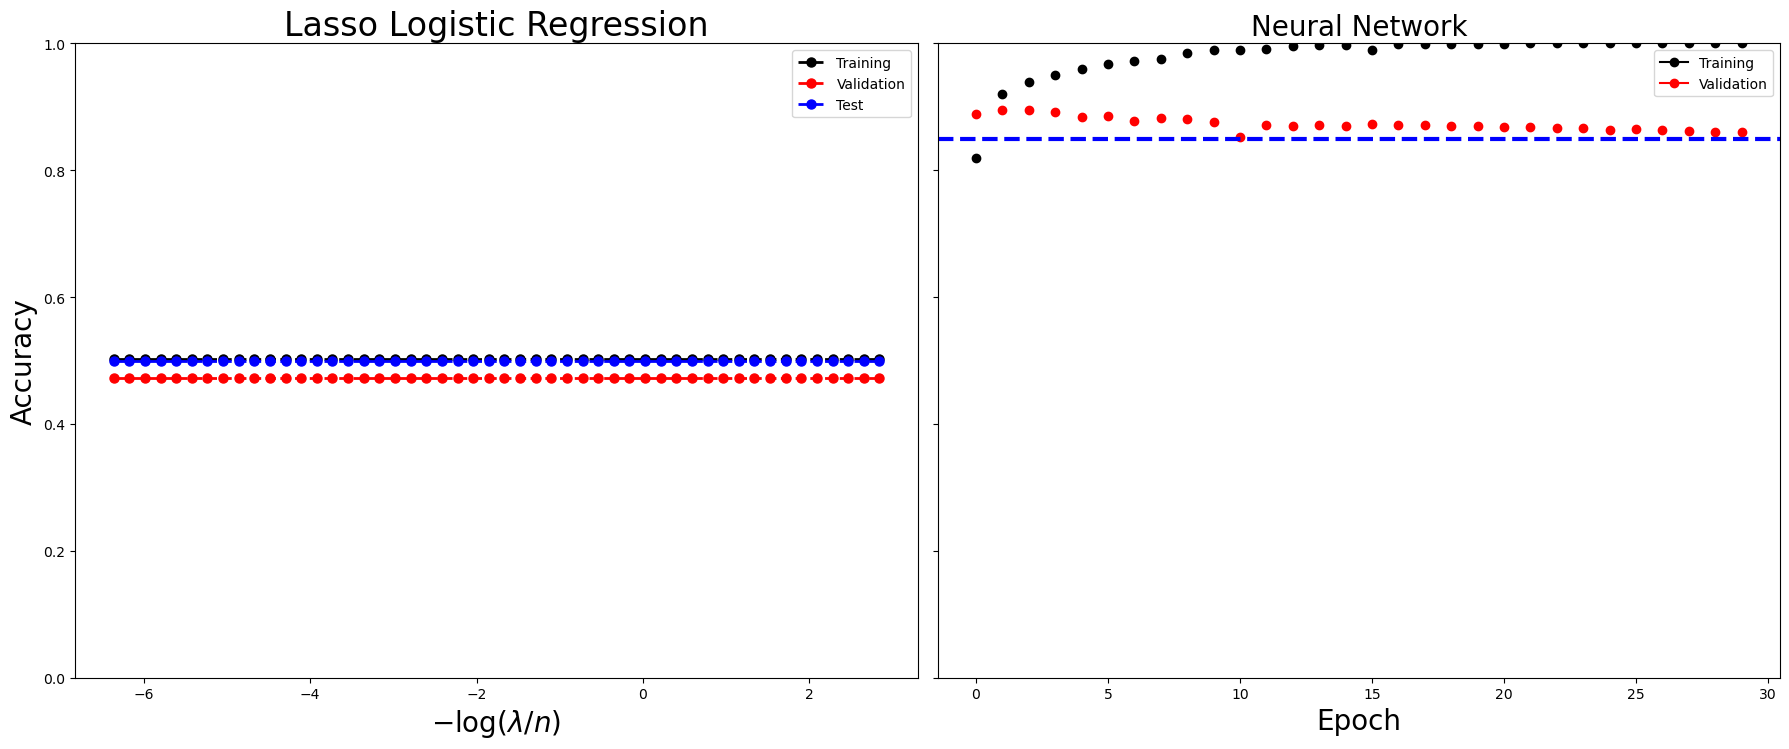

In [37]:
# Reading the log file and plotting training/validation accuracy
imdb_results = pd.read_csv(imdb_logger.experiment.metrics_file_path)
summary_plot(imdb_results,
             axes[1],
             col="accuracy",
             ylabel="Accuracy")
axes[1].set_xticks(np.linspace(0, 30, 7).astype(int))
axes[1].set_ylim([0.0, 1.0])
axes[1].set_ylabel("Accuracy", fontsize=20)     
axes[1].set_xlabel("Epoch", fontsize=20)
axes[1].set_title("Neural Network", fontsize=20)
axes[1].axhline(test_results[0]["test_accuracy"], color="blue", linestyle="--", label="NN Test Accuracy", linewidth=3)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig

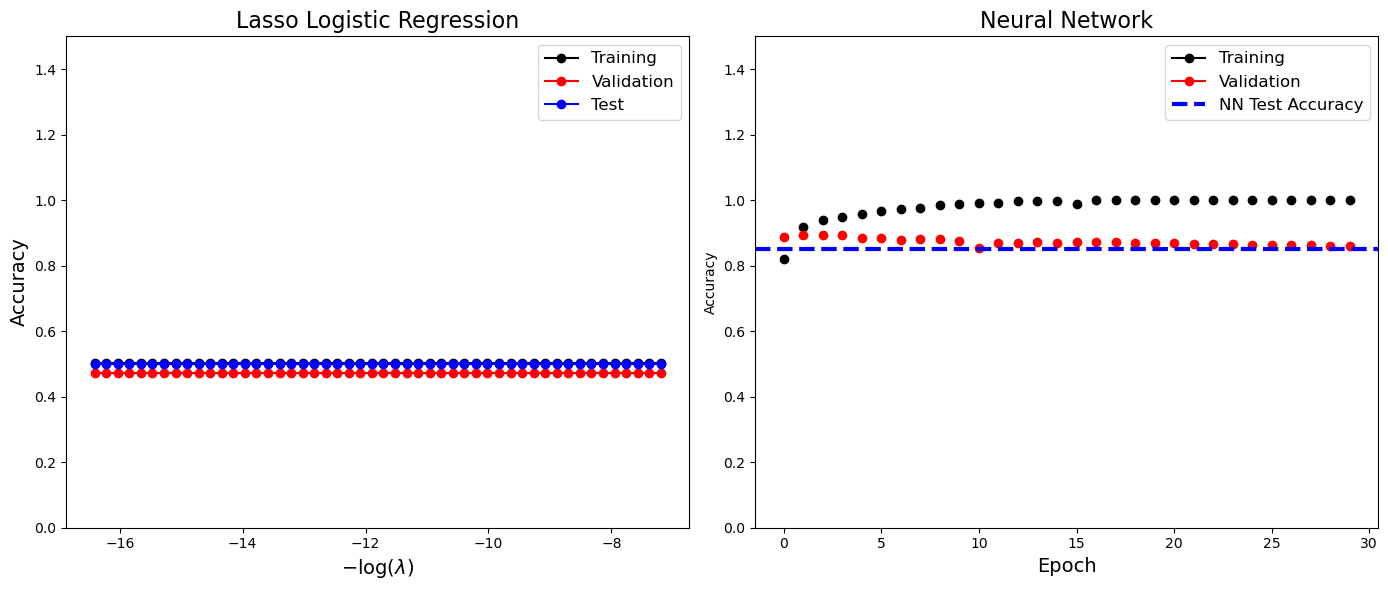

In [ ]:
# --- Compute accuracies per lambda ---
accuracy_train, accuracy_valid, accuracy_test = [], [], []

for (X_, Y_) in [ (X_train, Y_train), (X_valid, Y_valid), (X_test, Y_test) ]:
    linpred_ = X_ * coefs.T + intercepts[None, :]   # (n_samples × n_lambdas)
    label_ = (linpred_ > 0).astype(int)             # predictions for each lambda
    accs_ = [np.mean(Y_ == l) for l in label_.T]    # accuracy per lambda
    if (X_ is X_train):
        accuracy_train = accs_
    elif (X_ is X_valid):
        accuracy_valid = accs_
    else:
        accuracy_test = accs_

# --- Now Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

axes[0].plot(-np.log(lam_val), accuracy_train, 'o-', color='black', label="Training")
axes[0].plot(-np.log(lam_val), accuracy_valid, 'o-', color='red', label="Validation")
axes[0].plot(-np.log(lam_val), accuracy_test, 'o-', color='blue', label="Test")
axes[0].legend(fontsize=12)
axes[0].set_xlabel(r"$-\log(\lambda)$", fontsize=14)
axes[0].set_ylabel("Accuracy", fontsize=14)
axes[0].set_title("Lasso Logistic Regression", fontsize=16)
axes[0].set_ylim(0.0, 1.0)

# Neural Network Plot
summary_plot(imdb_results, axes[1], col="accuracy", ylabel="Accuracy")
axes[1].axhline(test_results[0]["test_accuracy"], color="blue", linestyle="--", label="NN Test Accuracy", linewidth=3)
axes[1].set_xlabel("Epoch", fontsize=14)
axes[1].set_title("Neural Network", fontsize=16)
axes[1].legend(fontsize=12)
axes[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()


In [31]:
logit.fit(X_train, Y_train)

#get predictions on test set
test_preds = logit.predict(X_test)
test_accuracy = np.mean(test_preds == Y_test)
print("Lasso Logistic Regression Test Accuracy:", test_accuracy)

Lasso Logistic Regression Test Accuracy: 0.5


##### The accuracy test score is 50% meaning that the Lasso did not learn anything meaningful from the data. We therefore relax the regularization parameter C to C=1. This yields a test accuracy of 86.6%.

In [39]:
import numpy as np
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Y_train mean (pos fraction):", Y_train.mean())
print("Y_test mean (pos fraction):", Y_test.mean())


Train size: (23000, 10003)
Test size: (25000, 10003)
Y_train mean (pos fraction): 0.4975652
Y_test mean (pos fraction): 0.5


In [40]:
coefs = logit.coef_.ravel()
print("Non-zero coefficients:", np.count_nonzero(coefs))
print("L0 fraction:", np.count_nonzero(coefs) / coefs.size)
print("Coef norm:", np.linalg.norm(coefs))
print("Intercept:", logit.intercept_)


Non-zero coefficients: 0
L0 fraction: 0.0
Coef norm: 0.0
Intercept: [0.]


In [41]:
logit = LogisticRegression(
    penalty="l1",
    C=1,  # instead of 1/lam_max
    solver="liblinear",
    warm_start=True,
    fit_intercept=True
)
logit.fit(X_train, Y_train)

print("Test Accuracy:", logit.score(X_test, Y_test))
print("Nonzero Coefficients:", np.count_nonzero(logit.coef_))


Test Accuracy: 0.86636
Nonzero Coefficients: 4110


C=0.0010 -> Test Accuracy=0.5976, Nonzeros=2
C=0.1120 -> Test Accuracy=0.8777, Nonzeros=959
C=0.2230 -> Test Accuracy=0.8809, Nonzeros=1728
C=0.3340 -> Test Accuracy=0.8786, Nonzeros=2331
C=0.4450 -> Test Accuracy=0.8782, Nonzeros=2854
C=0.5560 -> Test Accuracy=0.8759, Nonzeros=3242
C=0.6670 -> Test Accuracy=0.8733, Nonzeros=3537
C=0.7780 -> Test Accuracy=0.8704, Nonzeros=3765
C=0.8890 -> Test Accuracy=0.8681, Nonzeros=3946
C=1.0000 -> Test Accuracy=0.8664, Nonzeros=4124


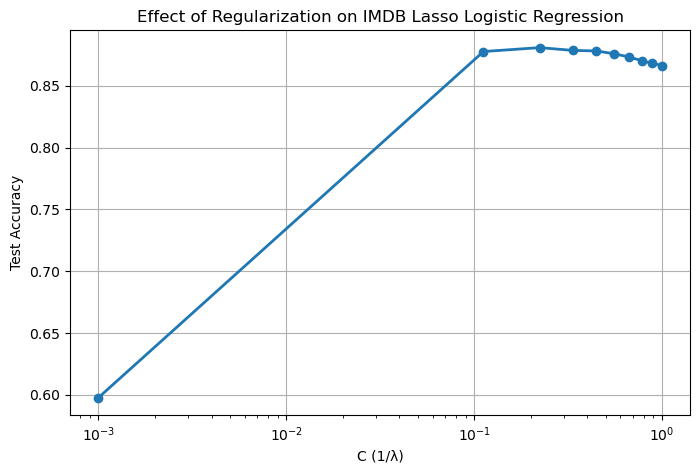

In [57]:
Cs = np.linspace(0.001, 1.0, 10)  # from 0.001 to 100
accs = []

for C in Cs:
    logit.C = C
    logit.fit(X_train, Y_train)
    acc = logit.score(X_test, Y_test)
    accs.append(acc)
    print(f"C={C:.4f} -> Test Accuracy={acc:.4f}, Nonzeros={np.count_nonzero(logit.coef_)}")

plt.figure(figsize=(8,5))
plt.semilogx(Cs, accs, 'o-', linewidth=2)
plt.xlabel("C (1/λ)")
plt.ylabel("Test Accuracy")
plt.title("Effect of Regularization on IMDB Lasso Logistic Regression")
plt.grid(True)
plt.show()


In [51]:
Cs = np.linspace(0.001, 1.0, 50)  # from 0.001 to 1.0
coefs= []
intercepts =[]

logit = LogisticRegression(
    penalty="l1",
    C=1,  # instead of 1/lam_max
    solver="liblinear",
    warm_start=True,
    fit_intercept=True
)

for C in Cs:
    logit.C = C
    logit.fit(X_train, Y_train)
    coefs.append(logit.coef_.copy())
    intercepts.append(logit.intercept_.copy())  

coefs = np.squeeze(coefs)
intercepts = np.squeeze(intercepts)

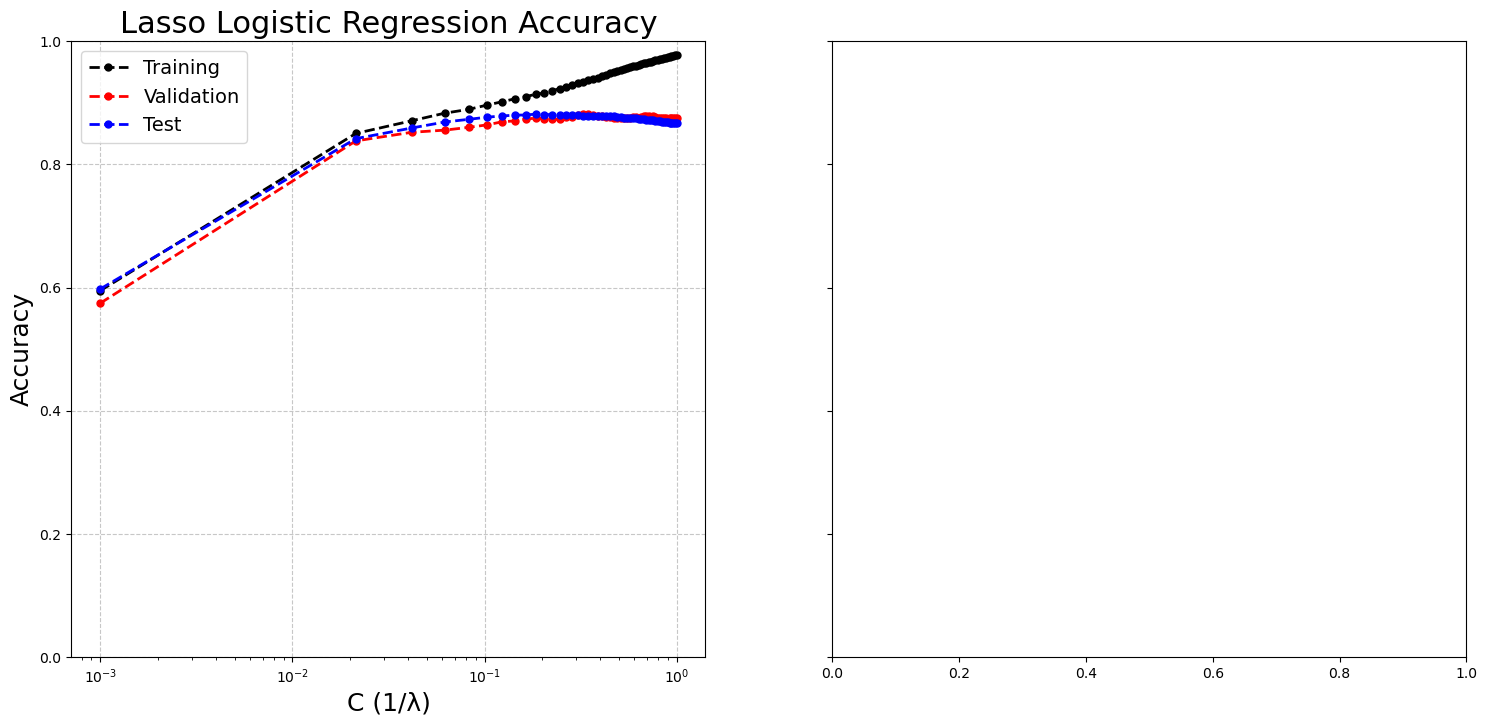

In [ ]:
fig, axes = subplots(1, 2, figsize=(18,8), sharey=True)
for ((X_, Y_), data_, color) in zip([(X_train, Y_train),(X_valid, Y_valid),(X_test, Y_test)],
                                   ["Training", "Validation", "Test"],
                                   ["black", "red", "blue"]):
    linpred_ = X_ @ coefs.T + intercepts[None, :]
    label_ = np.array(linpred_ > 0)
    accuracy_ = np.array([np.mean(Y_ == l) for l in label_.T])
    axes[0].semilogx(Cs, accuracy_, ".--", color=color, label=data_, markersize=10, linewidth=2) #plt.semilogx() is just lile plt.plot except it uses a logarithmic scale for the x-axis while keeping the y-axis linear
axes[0].legend(fontsize=14)
axes[0].set_xlabel("C (1/λ)", fontsize=18)
axes[0].set_ylabel("Accuracy", fontsize=18)
axes[0].set_title("Lasso Logistic Regression Accuracy", fontsize=22)
axes[0].set_ylim([0.0, 1.0])
axes[0].grid(True, linestyle="--", alpha=0.7)    

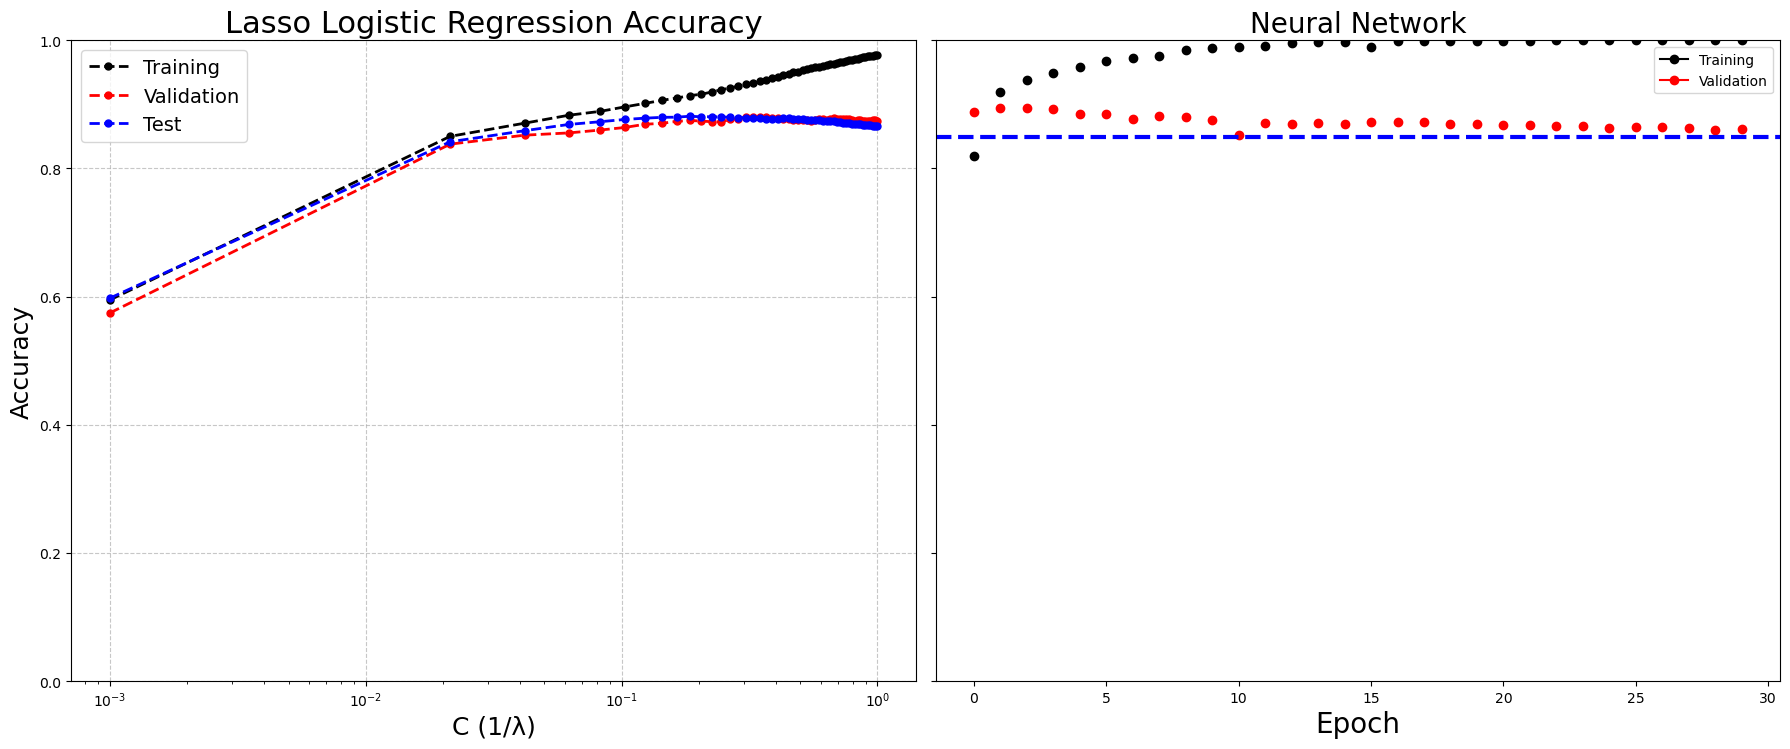

In [53]:
imdb_results = pd.read_csv(imdb_logger.experiment.metrics_file_path)
summary_plot(imdb_results,
             axes[1],
             col="accuracy",
             ylabel="Accuracy")
axes[1].set_xticks(np.linspace(0, 30, 7).astype(int))
axes[1].set_ylim([0.0, 1.0])
axes[1].set_ylabel("Accuracy", fontsize=20)     
axes[1].set_xlabel("Epoch", fontsize=20)
axes[1].set_title("Neural Network", fontsize=20)
axes[1].axhline(test_results[0]["test_accuracy"], color="blue", linestyle="--", label="NN Test Accuracy", linewidth=3)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig

In [58]:
#once again we end with a cleanup
del(imdb_train, imdb_test, imdb_dm, imdb_logger, imdb_trainer, imdb_model)

#### Recurrent Neural Network

##### Sequential Models for Document Classification
##### Here we fit a simple LSTM RNN for sentiment prediction to the IMDB movie review data. For an RNN we use the sequence of words in a document, taking the order into account. We loaded the preprocessed data at the beginning. Notably since more than 90% of the documents had fewer than 500 words, we set the document length to 500. For longer documents, we used the last 500 words, and for shorter documents, we padded the front with blanks.

In [72]:
imdb_seq_dm = SimpleDataModule(imdb_seq_train,
                              imdb_seq_test,
                              validation=2000,
                              batch_size=300,
                              num_workers= min(6, max_num_workers))

##### The first layer of the RNN is an embedding layer of size 32, which will be learned during training. This layer one-hot encodes each document as a matrix of dimension 500 x 10,003 and then maps these 10,003 dimensions down to 32. Since each word is represented by an integer, this is effectively achieved by the creation of an embedding matrix of size 10,003 x 32; each of the 500 integers in the document are then mapped to the appropriate 32 real numbers by indexing the appropriate rows of this matrix.
##### The second layer is an LSTM with 32 units, and the output layer is a single logit for the binary classification task. In the last line of the **forward()** method below, we take the last 32 dimensional output of the LSTM and map it to our response.

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super(LSTMModel, self).__init__()   
        self.embedding = nn.Embedding(input_size, 32)
        self.lstm = nn.LSTM(input_size=32,
                            hidden_size=32,
                            batch_first=True)
        self.dense = nn.Linear(32, 1)
    def forward(self, x):
        val, (h_n, c_n) = self.lstm(self.embedding(x))
        return torch.flatten(self.dense(val[:,-1])) #use the output at the last time step only    

# self.lstm takes the embedded sequences and processes them sequentially through the LSTM layer.  
# Returns two thigs: val, which contains the output features from the LSTM for all time steps, and (h_n, c_n), which are the hidden and cell states at the last time step.
# We use val[:, -1] to select the output corresponding to the last time step for each sequence in the batch. This output is then passed through a linear layer to produce the final prediction.  

In [ ]:
# We instantiate and summarize the model
vocab_size = 10003 # IMDB dataset default dictionary size
lstm_model = LSTMModel(input_size=vocab_size)
summary(lstm_model,
       input_data=imdb_seq_test.tensors[0][:10],
       col_names=["input_size", "output_size", "num_params"])   

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LSTMModel                                [10, 500]                 [10]                      --
├─Embedding: 1-1                         [10, 500]                 [10, 500, 32]             320,096
├─LSTM: 1-2                              [10, 500, 32]             [10, 500, 32]             8,448
├─Linear: 1-3                            [10, 32]                  [10, 1]                   33
Total params: 328,577
Trainable params: 328,577
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 45.44
Input size (MB): 50.00
Forward/backward pass size (MB): 2.56
Params size (MB): 1.31
Estimated Total Size (MB): 53.87

In [75]:
lstm_module = SimpleModule.binary_classification(lstm_model, optimizer=RMSprop(lstm_model.parameters(), lr=0.001))

lstm_logger = CSVLogger("logs", name="IMDB_LSTM")

In [76]:
lstm_trainer = Trainer(deterministic=True,
                       max_epochs=20,
                       logger=lstm_logger,
                       callbacks=[ErrorTracker()])
lstm_trainer.fit(lstm_module, datamodule=imbd_seq_dm)   

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | LSTMModel         | 328 K  | train
1 | loss  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
328 K     Trainable params
0         Non-trainable params
328 K     Total params
1.314     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|██████████| 77/77 [00:37<00:00,  2.07it/s, v_num=2]          

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 77/77 [00:37<00:00,  2.06it/s, v_num=2]


In [78]:
#We track the test performance as the network is fit
lstm_trainer.test(lstm_module, datamodule=imdb_seq_dm)

Testing DataLoader 0: 100%|██████████| 84/84 [00:03<00:00, 24.74it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.8575599789619446
        test_loss           0.3728311061859131
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.3728311061859131, 'test_accuracy': 0.8575599789619446}]

Text(0.5, 1.0, 'LSTM on IMDB Dataset')

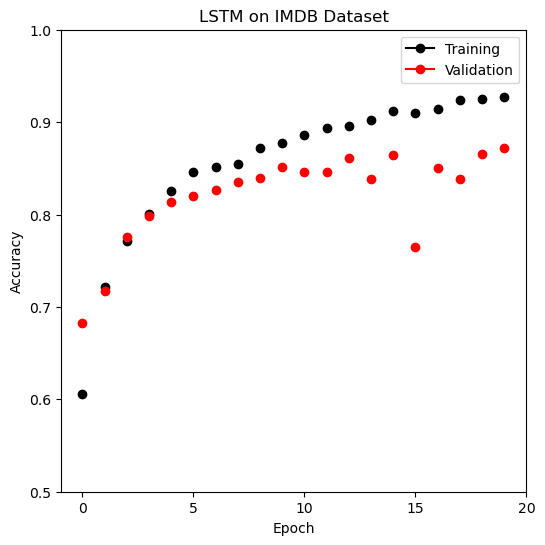

In [79]:
# We plot the learning progress

lstm_results = pd.read_csv(lstm_logger.experiment.metrics_file_path)
fig, ax = subplots(1, 1, figsize=(6,6))
summary_plot(lstm_results,
             ax,
             col="accuracy",
             ylabel="Accuracy")
ax.set_xticks(np.linspace(0, 20, 5).astype(int))
ax.set_ylim([0.5, 1])       
ax.set_ylabel("Accuracy")
ax.set_title("LSTM on IMDB Dataset")


In [80]:
# Lets clean up
del(lstm_model,
 lstm_trainer,
 lstm_logger,
 imdb_seq_dm,
 imdb_seq_train,
 imdb_seq_test)

#### Time Series Prediction

##### We now show how to fit the models for time series prediction. We load and standardize the data.

In [37]:
NYSE = load_data("NYSE")
cols =["DJ_return", "log_volume", "log_volatility"]
X = pd.DataFrame(StandardScaler(with_mean=True, with_std=True).fit_transform(NYSE[cols]),
                 columns=NYSE[cols].columns,
                 index = NYSE.index)

In [38]:
# Next we set up the lagged versions of the data, dropping any rows with missing values

for lag in range(1,6): #loop over lags 1 to 5
    for col in cols: # loop over each column
        newcol = np.zeros(X.shape[0]) * np.nan # initialize new column with NaNs
        newcol[lag:] = X[col].values[:-lag] #shift data down by lag
        X.insert(len(X.columns), "{0}_{1}".format(col, lag), newcol) # insert new column at the end of DataFrame
X.insert(len(X.columns), "train", NYSE["train"]) # add train column
X.dropna(inplace=True) # drop rows with NaNs   

In [ ]:
# Lets do the above  using pandas shift() function  
#for lag in range(1,6):
 #   for col in cols:
  #      X["{0}_{1}".format(col, lag)] = X[col].shift(lag)
#X.insert(len(X.columns), "train", NYSE["train"])
#X.dropna()

,DJ_return,log_volume,log_volatility,DJ_return_1,log_volume_1,log_volatility_1,DJ_return_2,log_volume_2,log_volatility_2,DJ_return_3,log_volume_3,log_volatility_3,DJ_return_4,log_volume_4,log_volatility_4,DJ_return_5,log_volume_5,log_volatility_5,train
date,,,,,,,,,,,,,,,,,,,
1962-12-10,-1.304126,0.605918,-1.366028,0.046340,0.224779,-2.500970,-0.431397,0.935176,-2.366521,0.434813,2.283789,-2.418037,0.905200,1.517291,-2.529058,-0.549823,0.175075,-4.357078,True
1962-12-11,-0.006294,-0.013661,-1.505667,-1.304126,0.605918,-1.366028,0.046340,0.224779,-2.500970,-0.431397,0.935176,-2.366521,0.434813,2.283789,-2.418037,0.905200,1.517291,-2.529058,True
1962-12-12,0.377081,0.042552,-1.551515,-0.006294,-0.013661,-1.505667,-1.304126,0.605918,-1.366028,0.046340,0.224779,-2.500970,-0.431397,0.935176,-2.366521,0.434813,2.283789,-2.418037,True
1962-12-13,-0.411718,-0.419836,-1.597607,0.377081,0.042552,-1.551515,-0.006294,-0.013661,-1.505667,-1.304126,0.605918,-1.366028,0.046340,0.224779,-2.500970,-0.431397,0.935176,-2.366521,True
1962-12-14,0.508785,-0.556065,-1.564386,-0.411718,-0.419836,-1.597607,0.377081,0.042552,-1.551515,-0.006294,-0.013661,-1.505667,-1.304126,0.605918,-1.366028,0.046340,0.224779,-2.500970,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1986-12-24,0.751210,-0.974763,0.046886,-0.750046,1.964846,0.080250,-0.185178,1.602669,0.128004,0.968266,4.258402,0.263406,-0.360744,0.143003,0.252350,-1.118959,-0.149916,0.375045,False
1986-12-26,0.195352,-5.623814,-0.083983,0.751210,-0.974763,0.046886,-0.750046,1.964846,0.080250,-0.185178,1.602669,0.128004,0.968266,4.258402,0.263406,-0.360744,0.143003,0.252350,False
1986-12-29,-1.148951,-1.553082,0.019967,0.195352,-5.623814,-0.083983,0.751210,-0.974763,0.046886,-0.750046,1.964846,0.080250,-0.185178,1.602669,0.128004,0.968266,4.258402,0.263406,False


In [39]:
# Finally we extract the response, training indicator, and drop the current day's Dj_return and log_volatility to predict only from previous day's data

Y, train = X["log_volume"], X["train"]
X = X.drop(columns=["train"] + cols)
X.columns

Index(['DJ_return_1', 'log_volume_1', 'log_volatility_1', 'DJ_return_2',
       'log_volume_2', 'log_volatility_2', 'DJ_return_3', 'log_volume_3',
       'log_volatility_3', 'DJ_return_4', 'log_volume_4', 'log_volatility_4',
       'DJ_return_5', 'log_volume_5', 'log_volatility_5'],
      dtype='object')

In [40]:
# We first fit a simple linear model and compute the R² on the test data using the score() method
M = LinearRegression()
M.fit(X[train], Y[train])
M.score(X[~train], Y[~train])

0.4128912938562521

In [42]:
# We refit this model, including the factor day_of_week as a categorical variable using one-hot encoding
X_day = pd.merge(X,
                 pd.get_dummies(NYSE["day_of_week"]),
                                on="date")

In [43]:
#We do not have to reinstantiate the linear regression model as its fit() method accepts design matrix and a response directly

M.fit(X_day[train], Y[train])
M.score(X_day[~train], Y[~train])

0.45955631330532754

##### To fit the RNN, we must reshape the data, as it will expect 5 lagged versions of each feature as indicated by the input_shape argument to the layer nn.RNN(). We first ensure the columns of our data frame are such that a reshaped matrix will have the variables correctly lagged. We use the reindex() method to do this.
##### For an input shape (5,3), each row reps a lagged version of the three variables. The nn.RNN() layer also expects the first row of each observation to be earliest in time, so we must reverse the current order. Hence we loop over range(5, 0, -1).

In [ ]:
ordered_cols= []
for lag in range(5, 0, -1):
    for col in cols:
        ordered_cols.append("{0}_{1}".format(col, lag)) 
X = X.reindex(columns= ordered_cols)
X.columns  

# RNN models expect the data to be shape like (samples, time_steps, features)

Index(['DJ_return_5', 'log_volume_5', 'log_volatility_5', 'DJ_return_4',
       'log_volume_4', 'log_volatility_4', 'DJ_return_3', 'log_volume_3',
       'log_volatility_3', 'DJ_return_2', 'log_volume_2', 'log_volatility_2',
       'DJ_return_1', 'log_volume_1', 'log_volatility_1'],
      dtype='object')

In [ ]:
#We now reshape the data

X_rnn = X.to_numpy().reshape((-1, 5, 3))
X_rnn.shape

(6046, 5, 3)

##### Now we are ready to proceed with the RNN, which uses 12 hidden units, and 10% dropout. After passing through the RNN, we extract the final time point in forward(). This gets passed through a 10% dropout and then flattened through a linear layer.

In [52]:
class NYSEModel(nn.Module):
    def __init__(self):
        super(NYSEModel, self).__init__()
        self.rnn = nn.RNN(3, 12, batch_first=True)
        self.dense = nn.Linear(12, 1)
        self.dropout = nn.Dropout(0.1)
    def forward(self, x):
        val, h_n = self.rnn(x)
        val = self.dropout(val)
        return torch.flatten(self.dense(val[:, -1]))    
nyse_model = NYSEModel()   
       

In [50]:
#Lets form the training dataset

datasets = []
for mask in [train, ~train]:
    X_tensor = torch.tensor(X_rnn[mask].astype(np.float32))
    Y_tensor = torch.tensor(Y[mask].astype(np.float32)) 
    datasets.append(TensorDataset(X_tensor, Y_tensor))  
nyse_train, nyse_test = datasets        

C:\Users\colli\AppData\Local\Temp\ipykernel_24236\3063633801.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y_tensor = torch.tensor(Y[mask].astype(np.float32))
C:\Users\colli\AppData\Local\Temp\ipykernel_24236\3063633801.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y_tensor = torch.tensor(Y[mask].astype(np.float32))


In [51]:
#lets inspect the summary

summary(nyse_model,
        input_data = X_tensor,
        col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
NYSEModel                                [1770, 5, 3]              [1770]                    --
├─RNN: 1-1                               [1770, 5, 3]              [1770, 5, 12]             204
├─Dropout: 1-2                           [1770, 5, 12]             [1770, 5, 12]             --
├─Linear: 1-3                            [1770, 12]                [1770, 1]                 13
Total params: 217
Trainable params: 217
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.83
Input size (MB): 0.11
Forward/backward pass size (MB): 0.86
Params size (MB): 0.00
Estimated Total Size (MB): 0.97

In [54]:
#We again put the two datasets into a data module, with a batch size of 64
max_num_workers = rec_num_workers()
nyse_dm = SimpleDataModule(nyse_train,
                           nyse_test,
                           batch_size=64,
                           num_workers=min(4, max_num_workers)) 

In [55]:
#We run some data through our model to be sure the sizes match up correctly

for idx, (x, y) in enumerate(nyse_dm.train_dataloader()):
    out = nyse_model(x)
    print(y.size(), out.size())
    if idx >=2:
        break

torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64])


In [57]:
#we follow our previous example for setting up a trainer for a regression problem, requesting the R2 metric to be computed at each epoch

nyse_optimizer = RMSprop(nyse_model.parameters(), lr=0.001)
nyse_module = SimpleModule.regression(nyse_model, optimizer=nyse_optimizer, metrics={"r2":R2Score()})

In [58]:
#lets fit the model

nyse_trainer = Trainer(deterministic=True,
                       max_epochs=200,
                       callbacks=[ErrorTracker()])
nyse_trainer.fit(nyse_module, datamodule=nyse_dm)   
#Finally we evaluate the test performance
nyse_trainer.test(nyse_module, datamodule=nyse_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | NYSEModel | 217    | train
1 | loss  | MSELoss  

c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\pytorch_lightning\utilities\data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.


Epoch 199: 100%|██████████| 67/67 [00:00<00:00, 112.20it/s, v_num=4]

`Trainer.fit` stopped: `max_epochs=200` reached.


Testing DataLoader 0: 100%|██████████| 28/28 [00:00<00:00, 192.30it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.6234346628189087
         test_r2            0.4083300828933716
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6234346628189087, 'test_r2': 0.4083300828933716}]

##### **AR** - Autoregressive model is a type of time series that predicts a variable using its own past values. AR model is the classical, linear version of what RNNs and LSTMs do in a nonlinear, more powerful way.
##### We could also fit a model without the **nn.RNN()** layer by just using a **nn.Flatten()** layer instead. This would be a nonlinear AR model. If in addition we excluded the hidden layer, this would be equivalent to our earlier linear AR model. Instead we will fit a nonlinear AR model using the feature set **X_day** that includes the day_of_week indicators. 


In [60]:
datasets = []
for mask in [train, ~train]:
    X_day_tensor = torch.tensor(np.asarray(X_day[mask]).astype(np.float32))
    Y_tensor = torch.tensor(Y[mask].astype(np.float32)) 
    datasets.append(TensorDataset(X_day_tensor, Y_tensor))  
day_train, day_test = datasets


C:\Users\colli\AppData\Local\Temp\ipykernel_24236\378128754.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y_tensor = torch.tensor(Y[mask].astype(np.float32))
C:\Users\colli\AppData\Local\Temp\ipykernel_24236\378128754.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y_tensor = torch.tensor(Y[mask].astype(np.float32))


In [61]:
#create a data module for the day data
day_dm = SimpleDataModule(day_train,
                           day_test,
                           batch_size=64,
                           validation=day_test,
                           num_workers=min(4, max_num_workers))

In [62]:
# We build a NonLinearARModel() that takes a input the 20 features and a hidden layer with 32 units.

class NonLinearARModel(nn.Module):
    def __init__(self):
        super(NonLinearARModel, self).__init__()
        self._forward = nn.Sequential(
            nn.Flatten(),
            nn.Linear(20, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1))
    def forward(self, x):
        return torch.flatten(self._forward(x))
            

In [ ]:
nl_model = NonLinearARModel()
nl_optimizer = RMSprop(nl_model.parameters(), lr=0.001)
nl_module = SimpleModule.regression(nl_model, optimizer=nl_optimizer, metrics={"r2":R2Score()})
nl_trainer = Trainer(deterministic=True,
                       max_epochs=20,
                       callbacks=[ErrorTracker()])
nl_trainer.fit(nl_module, datamodule=day_dm)   
#Finally we evaluate the test performance   
nl_trainer.test(nl_module, datamodule=day_dm)

# We see the test R² is a slight improvement over the linear AR model that also used the day_of_week factor.

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | NonLinearARModel | 705    | train
1 | loss  | MSELoss          | 0      | train
---------------------------------------------------
705       Trainable params
0         Non-trainable params
705       Total params
0.003     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|██████████| 67/67 [00:00<00:00, 98.98it/s, v_num=5]           

`Trainer.fit` stopped: `max_epochs=20` reached.


Testing DataLoader 0: 100%|██████████| 28/28 [00:00<00:00, 243.00it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.5634903311729431
         test_r2            0.46522021293640137
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.5634903311729431, 'test_r2': 0.46522021293640137}]

#### Question 1

##### Fit a neural network to the **Default** data. Use a single hidden layer with 10 units, and a dropout regularization. Compare the classification performance of your model with that of linear logistic regression.

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
#load the data
Default = load_data("Default").dropna()
Default.shape

(10000, 4)

In [55]:
#lets set up the model matrix and the response
#encode categorical variables using one-hot encoding
X = pd.get_dummies(Default.drop(columns=["default"]), drop_first=True)

#encode response as binary variable
Y = pd.get_dummies(Default["default"], drop_first=True)


In [56]:
#We split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [57]:
#scale the features
scaler = StandardScaler(with_mean=True, with_std=True)
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)
                      

In [58]:
#fit logistic regression using sklearn
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, Y_train)


c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
#evaluate the performance
Y_pred = logit.predict(X_test)
acc = accuracy_score(Y_test, Y_pred)
acc

0.9715

In [ ]:
#lets fit the neural network model and compare
class DefaultModel(nn.Module):
    def __init__(self, input_size):
        super(DefaultModel, self).__init__()
        self.flatten = nn.Flatten()
        self.model = nn.Sequential(
            nn.Linear(input_size, 10),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(10, 1),
            nn.Sigmoid() # an activation function to output probabilities between 0 and 1
        )
    def forward(self, x):
        x = self.flatten(x) 
        return torch.flatten(self.model(x))

In [ ]:
#prepare data for PyTorch
X_train_tensor = torch.tensor(X_train.astype(np.float32))
Y_train_tensor = torch.tensor(Y_train.values.astype(np.float32)).flatten()      
X_test_tensor = torch.tensor(X_test.astype(np.float32))
Y_test_tensor = torch.tensor(Y_test.values.astype(np.float32)).flatten()

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)  

max_num_workers = rec_num_workers()
default_dm = SimpleDataModule(train_dataset,
                              test_dataset,
                              batch_size=64,
                              validation=test_dataset,
                              num_workers=min(4, max_num_workers))


In [70]:
default_model = DefaultModel(input_size=X_train.shape[1])
summary(default_model,
       input_data=X_train_tensor[:10],
       col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DefaultModel                             [10, 3]                   [10]                      --
├─Flatten: 1-1                           [10, 3]                   [10, 3]                   --
├─Sequential: 1-2                        [10, 3]                   [10, 1]                   --
│    └─Linear: 2-1                       [10, 3]                   [10, 10]                  40
│    └─ReLU: 2-2                         [10, 10]                  [10, 10]                  --
│    └─Dropout: 2-3                      [10, 10]                  [10, 10]                  --
│    └─Linear: 2-4                       [10, 10]                  [10, 1]                   11
Total params: 51
Trainable params: 51
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.10
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.10

In [ ]:
for idx, (x, y) in enumerate(default_dm.train_dataloader()):
    out = default_model(x)
    print(y.size(), out.size())
    if idx >=2:
        break
 


torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64])


In [72]:
default_optimizer = RMSprop(default_model.parameters(), lr=0.001)
default_module = SimpleModule.binary_classification(default_model, optimizer=default_optimizer) 
default_logger = CSVLogger("logs", name="Default")
default_trainer = Trainer(deterministic=True,
                       max_epochs=30,
                       logger=default_logger,
                       callbacks=[ErrorTracker()])
default_trainer.fit(default_module, datamodule=default_dm)
#Finally we evaluate the test performance
default_trainer.test(default_module, datamodule=default_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | DefaultModel      | 51     | train
1 | loss  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
51        Trainable params
0         Non-trainable params
51        Total params
0.000     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 29: 100%|██████████| 125/125 [00:01<00:00, 105.54it/s, v_num=0]       

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing DataLoader 0: 100%|██████████| 32/32 [00:00<00:00, 307.73it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9629999995231628
        test_loss           0.09772679209709167
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.09772679209709167, 'test_accuracy': 0.9629999995231628}]

In [73]:
from sklearn.metrics import classification_report

# Logistic regression predictions
Y_pred_log = logit.predict(X_test)

print("Logistic Regression Performance:")
print(classification_report(Y_test, Y_pred_log, digits=3))


Logistic Regression Performance:
              precision    recall  f1-score   support

       False      0.974     0.997     0.985      1926
        True      0.793     0.311     0.447        74

    accuracy                          0.972      2000
   macro avg      0.884     0.654     0.716      2000
weighted avg      0.967     0.972     0.965      2000



In [74]:
import torch

# Put model in eval mode and get predictions
default_model.eval()  # Lightning already handles this in Trainer, but for manual predictions
with torch.no_grad():
    probs_nn = default_model(torch.tensor(X_test, dtype=torch.float32))
    preds_nn = (probs_nn >= 0.5).int().numpy()

print("Neural Network Performance:")
print(classification_report(Y_test, preds_nn, digits=3))


Neural Network Performance:
              precision    recall  f1-score   support

       False      0.963     1.000     0.981      1926
        True      0.000     0.000     0.000        74

    accuracy                          0.963      2000
   macro avg      0.481     0.500     0.491      2000
weighted avg      0.927     0.963     0.945      2000



c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\colli\anaconda3\envs\dl_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh